# Import libraries

In [1]:
# %pip install ipywidgets

In [2]:
# Standard library imports
from pathlib import Path

# Third-party imports
import numpy as np
import tensorly as tl
from tqdm import tqdm

# Local TBMD module imports
from TBMD.modules.TensorHOSVD import TuckerDecomposer
from TBMD.modules.TensorTimeInsensitiveModes import (
    BatchModalProcessor, 
    ModalTensorStacker, 
    ModalProcessorConfig, 
    ProcessingStrategy,
    stack_all_modes, 
    process_all_subjects
)
from TBMD.modules.TensorBasedTubeFiberPivotQRFactorization import (
    TensorTubeQRDecomposition,
    TensorQRConfig
)

# from TBMD.modules.TensorBasedCompressiveSensing import (
#     TensorCompressiveSensing,
#     CompressiveSensingConfig,
# )

from TBMD.modules.TensorBasedCompressiveSensing import (
    TensorCompressiveSensing,
    CompressiveSensingConfig,
    ExtensionCompressiveSensingConfig
)

# TBMD utilities imports
from TBMD.utils.utils import (
    reconstruct_tensor, 
    build_Y_matrices, 
    to_torch_tensor, 
    generate_noisy_datasets,
    build_wells_matrix
)
from TBMD.utils.plots import (
    plot_two_matrices,
    plot_original_reconstructed_diff, 
    visualize_wells_placement, 
    visualize_tensor,
)
from TBMD.utils.metrics import compute_metrics
from TBMD.utils.process_data import (
    process_data, 
    calculate_global_minmax_params, 
    calculate_global_zscore_params, 
    inverse_normalization
)
from TBMD.utils.split_data import split_data_in_memory_ordered, split_data_in_memory
from TBMD.utils.Analytics import (
    ExperimentConfig,
    ExperimentRunner, 
    plot_analytics
)
from TBMD.config import SEED, SET_BACKEND

In [3]:
tl.check_random_state(SEED)
np.random.seed(SEED)

tl.set_backend(SET_BACKEND)

# Download data

### Load navier stokes data

In [4]:
# В этом блоке реализовано удаление "лишних" размерностей с помощью np.squeeze()
# Теперь добавлена поддержка тестовых данных с формой (N, T, H, W, 1, 1)
# Для тестовых данных: (samples, timesteps, H, W, 1, 1) -> (N, T, H, W)
# Для тренировочных: (N, H, W, 1, 1) -> (N, H, W)
# Последние размерности с 1 обычно не несут полезной информации

import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

def load_npy_file(file_path):
    """
    Load a single .npy file and return the array.
    Raises FileNotFoundError if the file does not exist.
    """
    file_path = Path(file_path)
    if not file_path.exists():
        raise FileNotFoundError(f"File {file_path} not found. Please check the path.")
    arr = np.load(file_path)
    # Если массив имеет 6 измерений (N, T, H, W, 1, 1) — squeeze только последние две размерности
    if arr.ndim == 6 and arr.shape[-1] == 1 and arr.shape[-2] == 1:
        arr = np.squeeze(arr, axis=(-1, -2))  # (N, T, H, W)
    # Если массив имеет 5 измерений (N, H, W, 1, 1) — squeeze последние две размерности
    elif arr.ndim == 5 and arr.shape[-1] == 1 and arr.shape[-2] == 1:
        arr = np.squeeze(arr, axis=(-1, -2))  # (N, H, W)
    else:
        arr = np.squeeze(arr) # General squeeze for other cases
    return arr

class DataLoaderNavierStokes:
    """
    DataLoader for Navier-Stokes datasets organized in train/test folders.
    Provides loading, batching, and visualization utilities.
    Data is stored internally as NumPy arrays with dimensions (H, W, N) or (H, W, T, N).
    """

    def __init__(self):
        # self.data will store {'train': {'inputs': np.ndarray, 'labels': np.ndarray}, 
        #                       'test':  {'inputs': np.ndarray, 'labels': np.ndarray}}
        self.data = {}

    def load(self, root_dir, load_train=True, load_test=True):
        """
        Load Navier-Stokes data from a directory containing 'train' and/or 'test'.
        Each subfolder should contain 'inputs.npy' and 'labels.npy'.

        Data is loaded as NumPy arrays and stored in self.data.
        Expected shapes for self.data[split][array_type]:
          - Train data: (H, W, N)
          - Test data: (H, W, T, N)
        where H is height, W is width, N is number of samples, T is timesteps.
        If loaded data from .npy file has fewer dimensions after squeezing 
        (e.g., a single sample resulting in (H,W) or (T,H,W) from file), 
        it's reshaped and transposed appropriately, with N as the last dimension.
        """
        root_dir = Path(root_dir)
        if not root_dir.exists():
            raise FileNotFoundError(f"Root directory {root_dir} not found.")

        self.data.clear()

        for split in ("train", "test"):
            if (split == "train" and not load_train) or \
               (split == "test" and not load_test):
                continue
            
            folder = root_dir / split
            if not folder.exists():
                print(f"Directory for '{split}' not found at {folder}. Skipping.")
                self.data[split] = {} # Ensure split key exists
                continue

            self.data[split] = {}
            for array_type in ("inputs", "labels"):
                file_path = folder / f"{array_type}.npy"
                try:
                    arr = load_npy_file(file_path) # Handles initial squeezing
                    
                    if split == "train":
                        # Expected from file after squeeze: (N, H, W) or (H, W)
                        if arr.ndim == 2: # Loaded as (H, W), treat as single sample
                            arr = arr[:, :, np.newaxis] # Convert to (H, W, 1)
                        elif arr.ndim == 3: # Loaded as (N, H, W)
                            arr = np.transpose(arr, (1, 2, 0)) # Convert to (H, W, N)
                        else:
                            raise ValueError(
                                f"Train data '{array_type}' at {file_path} has unexpected shape {arr.shape} "
                                f"after initial squeeze. Expected 2D (H,W) or 3D (N,H,W) from file to convert to (H,W,N)."
                            )
                        print(f"Loaded '{split}/{array_type}': final shape {arr.shape} (expected H, W, N)")
                        
                    elif split == "test":
                        # Expected from file after squeeze: (N, T, H, W) or (T, H, W)
                        if arr.ndim == 3: # Loaded as (T, H, W), treat as single sample
                            arr = np.transpose(arr, (1, 2, 0)) # Convert to (H, W, T)
                            arr = arr[:, :, :, np.newaxis]    # Convert to (H, W, T, 1)
                        elif arr.ndim == 4: # Loaded as (N, T, H, W)
                            arr = np.transpose(arr, (2, 3, 1, 0)) # Convert to (H, W, T, N)
                        else:
                            raise ValueError(
                                f"Test data '{array_type}' at {file_path} has unexpected shape {arr.shape} "
                                f"after initial squeeze. Expected 3D (T,H,W) or 4D (N,T,H,W) from file to convert to (H,W,T,N)."
                            )
                        print(f"Loaded '{split}/{array_type}': final shape {arr.shape} (expected H, W, T, N)")
                    
                    self.data[split][array_type] = arr

                except FileNotFoundError as e:
                    print(e)
                    self.data[split][array_type] = None 
                except ValueError as e:
                    print(f"Error processing {split}/{array_type} from {file_path}: {e}")
                    self.data[split][array_type] = None

        loaded_something = False
        if self.data:
            for split_key in self.data:
                if self.data[split_key]:
                    for array_key in self.data[split_key]:
                        if self.data[split_key][array_key] is not None:
                            loaded_something = True
                            break
                if loaded_something:
                    break
        
        if not loaded_something:
            raise RuntimeError("No data loaded. Check folder structure, file names, flags, and file contents.")
        return self.data

    def get_batch(self, split, array_type='inputs', batch_size=4, start_idx=0, time_idx=None):
        """
        Returns a NumPy array containing a batch of data.
        - For 'train' data (shape H,W,N): returns array of shape (H, W, B).
        - For 'test' data (shape H,W,T,N):
            - If time_idx is specified: returns array of shape (H, W, B) for that timestep.
            - If time_idx is None: returns array of shape (H, W, T, B) for all timesteps.
        B is the actual batch size (min(batch_size, N_available - start_idx)).
        H, W are spatial dimensions. T is number of timesteps. N is number of samples (last dimension).
        """
        if split not in self.data or array_type not in self.data[split] or \
           self.data[split][array_type] is None:
            if split in self.data and array_type in self.data[split] and self.data[split][array_type] is None:
                 raise ValueError(f"Data for '{split}/{array_type}' was not loaded successfully (is None).")
            raise KeyError(f"Data for '{split}/{array_type}' not found. Ensure it was loaded.")
        
        full_data_array = self.data[split][array_type]
        
        N_total_samples = full_data_array.shape[-1]

        if not isinstance(start_idx, int) or start_idx < 0:
            raise ValueError(f"start_idx must be a non-negative integer, got {start_idx}.")
        if not isinstance(batch_size, int) or batch_size <= 0:
            raise ValueError(f"batch_size must be a positive integer, got {batch_size}.")

        actual_end_idx = min(start_idx + batch_size, N_total_samples)

        if start_idx >= N_total_samples:
            if split == "train": # (H, W, N)
                H, W, _ = full_data_array.shape
                return np.empty((H, W, 0), dtype=full_data_array.dtype)
            elif split == "test": # (H, W, T, N)
                H, W, T, _ = full_data_array.shape
                if time_idx is not None:
                    return np.empty((H, W, 0), dtype=full_data_array.dtype)
                else:
                    return np.empty((H, W, T, 0), dtype=full_data_array.dtype)
        
        if split == "train": # full_data_array is (H, W, N_total)
            batch_data = full_data_array[:, :, start_idx:actual_end_idx] # (H, W, B)
            return batch_data

        elif split == "test": # full_data_array is (H, W, T, N_total)
            batch_data = full_data_array[:, :, :, start_idx:actual_end_idx] # (H, W, T, B)
            if time_idx is not None:
                T_dim_size = batch_data.shape[2] # T dimension
                if not isinstance(time_idx, int) or not (0 <= time_idx < T_dim_size):
                    if T_dim_size == 0 and time_idx == 0:
                         pass 
                    else:
                        raise IndexError(
                            f"time_idx {time_idx} is invalid or out of range for test data "
                            f"which has {T_dim_size} timesteps (0 to {T_dim_size-1})."
                        )
                return batch_data[:, :, time_idx, :] # -> (H, W, B)
            else:
                return batch_data # -> (H, W, T, B)
        else:
            raise ValueError(f"Unknown split: {split}. Must be 'train' or 'test'.")

    @staticmethod
    def visualize_data(data, index=0, title=None, time_idx=None):
        """
        Visualize a single 2D field sample from a NumPy array.
        Data shapes and indexing:
        - If data is (H, W, T, N): 'index' selects sample from N (last dim), 'time_idx' selects from T (third dim).
        - If data is (H, W, N): 'index' selects sample from N (last dim). 'time_idx' is ignored.
        - If data is (H, W): Single sample. 'index' and 'time_idx' are ignored (assumed 0).
        'time_idx' defaults to 0 if applicable and not provided.
        """
        if data is None or data.size == 0:
            raise ValueError("No data to visualize.")
        
        slice_2d = None
        tlabel = ""
        effective_index = index
        effective_title = title

        if not isinstance(effective_index, int):
            raise TypeError(f"index must be an integer, got {type(effective_index)}")

        if data.ndim == 4: # Assumed (H, W, T, N)
            H, W, T_dim, N_samples = data.shape
            if not (0 <= effective_index < N_samples):
                print(f"Warning: Sample index {effective_index} for visualization is out of range [0, {N_samples-1}]. Using index 0.")
                effective_index = 0 if N_samples > 0 else -1 
            
            current_time_idx = time_idx if time_idx is not None else 0
            if not isinstance(current_time_idx, int) or not (0 <= current_time_idx < T_dim):
                print(f"Warning: time_idx {current_time_idx} is invalid or out of range [0, {T_dim-1}]. Using time_idx 0.")
                current_time_idx = 0 if T_dim > 0 else -1
            
            if N_samples == 0 or T_dim == 0 :
                 print(f"Warning: Data has zero samples or timesteps (shape {data.shape}). Cannot select a slice.")
                 slice_2d = np.zeros((H if H > 0 else 1, W if W > 0 else 1), dtype=data.dtype) 
                 tlabel = " (N/A)"
            elif effective_index == -1 or current_time_idx == -1: # Should only happen if N_samples or T_dim was 0
                 slice_2d = np.zeros((H if H > 0 else 1, W if W > 0 else 1), dtype=data.dtype)
                 tlabel = " (N/A)"
            else:
                 slice_2d = data[:, :, current_time_idx, effective_index]
                 tlabel = f" (t={current_time_idx})"

            if effective_title is None: effective_title = f"Sample {effective_index if N_samples > 0 and effective_index != -1 else 'N/A'}"

        elif data.ndim == 3: # Assumed (H, W, N)
            H, W, N_samples = data.shape
            if not (0 <= effective_index < N_samples):
                print(f"Warning: Sample index {effective_index} for visualization is out of range [0, {N_samples-1}]. Using index 0.")
                effective_index = 0 if N_samples > 0 else -1
            
            if N_samples == 0 :
                print(f"Warning: Data has zero samples (shape {data.shape}). Cannot select a slice.")
                slice_2d = np.zeros((H if H > 0 else 1, W if W > 0 else 1), dtype=data.dtype)
            elif effective_index == -1: # Should only happen if N_samples was 0
                slice_2d = np.zeros((H if H > 0 else 1, W if W > 0 else 1), dtype=data.dtype)
            else:
                slice_2d = data[:, :, effective_index]
            if effective_title is None: effective_title = f"Sample {effective_index if N_samples > 0 and effective_index != -1 else 'N/A'}"
        
        elif data.ndim == 2: # Assumed (H, W)
            slice_2d = data
            if effective_index != 0: 
                 print(f"Warning: Index {effective_index} provided for 2D data (single sample). Displaying the sample.")
            if effective_title is None: effective_title = "Sample"
        
        else:
            raise ValueError(
                f"Data for visualize_data must be 2D (H,W), 3D (H,W,N), or 4D (H,W,T,N). "
                f"Got shape {data.shape}."
            )

        plt.figure(figsize=(8, 6))
        plt.imshow(np.squeeze(slice_2d), cmap='viridis') 
        plt.colorbar(label='Value')
        plt.title(str(effective_title) + tlabel)
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.tight_layout()
        plt.show()

    @staticmethod
    def visualize_multiple_samples(data, num_samples=4, figsize=(12, 10), super_title=None, time_idx=None):
        """
        Visualize multiple samples from a NumPy array in a grid.
        Expects data with samples along the last dimension:
        - (H, W, N): Visualizes up to 'num_samples' from N.
        - (H, W, T, N): Visualizes up to 'num_samples' from N, at a specific 'time_idx' from T (third dim).
                       'time_idx' defaults to 0 if None and T > 0.
        - (H, W): Treats as a single sample (N=1), visualizes it.
        """
        if data is None or data.size == 0:
            raise ValueError("No data to visualize (input data is None or empty).")
        
        processed_data_for_plotting = None 

        if data.ndim == 4: # (H, W, T, N)
            H, W, T_dim, N_samples = data.shape
            current_time_idx = time_idx if time_idx is not None else 0
            
            if N_samples == 0: 
                processed_data_for_plotting = np.empty((H, W, 0), dtype=data.dtype)
            elif T_dim == 0:
                print(f"Warning: Data has 0 timesteps (shape {data.shape}). Visualizing empty slices.")
                processed_data_for_plotting = np.zeros((H, W, N_samples), dtype=data.dtype) 
            else: # N_samples > 0 and T_dim > 0
                if not isinstance(current_time_idx, int) or not (0 <= current_time_idx < T_dim):
                    if time_idx is not None: 
                        print(f"Warning: time_idx {current_time_idx} for multi-sample visualization is invalid or out of range for T={T_dim}. Using 0.")
                    current_time_idx = 0 
                processed_data_for_plotting = data[:, :, current_time_idx, :] # -> (H, W, N_samples)

        elif data.ndim == 3: # (H, W, N)
            processed_data_for_plotting = data
        
        elif data.ndim == 2: # (H, W) 
            processed_data_for_plotting = data[:, :, np.newaxis] # -> (H, W, 1)
        
        else:
            raise ValueError(
                f"Data for visualize_multiple_samples must be 2D (H,W), 3D (H,W,N), or 4D (H,W,T,N). "
                f"Got shape {data.shape}."
            )
        
        N_effective = processed_data_for_plotting.shape[2] # Samples are in the last dimension
        
        if not isinstance(num_samples, int) or num_samples <=0:
            n_to_plot = N_effective
        else:
            n_to_plot = min(num_samples, N_effective)

        if n_to_plot == 0:
            print("No samples to visualize in visualize_multiple_samples (data might be empty, N_effective=0, or num_samples=0).")
            return
            
        grid_dim = int(np.ceil(np.sqrt(n_to_plot)))
        fig, axes = plt.subplots(grid_dim, grid_dim, figsize=figsize, squeeze=False)
        flat_axes = axes.flatten()

        im = None
        for i in range(n_to_plot):
            slice_2d = np.squeeze(processed_data_for_plotting[:, :, i]) 
            im = flat_axes[i].imshow(slice_2d, cmap='viridis')
            flat_axes[i].set_title(f"Sample {i}") 
            flat_axes[i].axis('off')
        
        for j in range(n_to_plot, len(flat_axes)):
            flat_axes[j].axis('off')
        
        if im:
            fig.subplots_adjust(right=0.9) 
            cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) 
            fig.colorbar(im, cax=cbar_ax, label='Value')
        
        if super_title:
            fig.suptitle(super_title, fontsize=16)
        
        plt.show()

    def visualize_batch(self, split, array_type='inputs', batch_size=4, start_idx=0, title=None, time_idx=None):
        """
        Convenience method: gets a batch as a NumPy array and visualizes it.
        - For 'train' data (batch shape H,W,B): visualizes samples from B.
        - For 'test' data:
            - If time_idx specified for get_batch (batch shape H,W,B): visualizes samples from B.
            - If time_idx=None for get_batch (batch shape H,W,T,B): visualizes samples from B 
              at the first timestep (t=0) by default (if T > 0).
        B is the number of samples in the batch (size of the last dimension).
        """
        try:
            batch_np = self.get_batch(split, array_type, batch_size, start_idx, time_idx=time_idx)
        except (KeyError, ValueError, IndexError) as e:
            print(f"Error getting batch for '{split}/{array_type}': {e}")
            return

        if batch_np is None or batch_np.size == 0:
            print(f"Batch for '{split}/{array_type}' is empty or invalid (start_idx={start_idx}, batch_size={batch_size}). Cannot visualize.")
            return

        num_actual_samples_in_batch = batch_np.shape[-1]
        if num_actual_samples_in_batch == 0: 
            print(f"Batch for '{split}/{array_type}' (start_idx={start_idx}) contains 0 samples. Cannot visualize.")
            return

        actual_displayed_end_idx = start_idx + num_actual_samples_in_batch - 1
        super_title_base = f"{split.capitalize()} {array_type} Batch (Original Indices {start_idx}-{actual_displayed_end_idx})"
        
        time_info_suffix = ""
        # vis_multi_time_idx_param is passed to visualize_multiple_samples.
        # If batch_np is (H,W,T,B), visualize_multiple_samples will use its own default time_idx=0 if this is None.
        # If batch_np is (H,W,B), visualize_multiple_samples ignores its time_idx param.
        vis_multi_time_idx_param = None 

        if split == "test":
            if time_idx is not None: # get_batch returned (H,W,B) for a specific timestep
                time_info_suffix = f", Displaying Timestep t={time_idx}"
                # visualize_multiple_samples will receive (H,W,B) data, so its time_idx param is not used.
            else: # get_batch returned (H,W,T,B)
                if batch_np.ndim == 4: # Should be (H,W,T,B)
                    T_dim_in_batch = batch_np.shape[2]
                    if T_dim_in_batch > 0:
                        # visualize_multiple_samples will default to t=0 for its display
                        time_info_suffix = f" (Default view: t=0 of T={T_dim_in_batch} total)"
                    else: 
                        time_info_suffix = " (No timesteps T=0 in data)"
                # If batch_np.ndim is not 4 here, it's an unexpected state, but title will be generic.
        
        final_super_title = title if title is not None else (super_title_base + time_info_suffix)
        
        self.visualize_multiple_samples(batch_np, 
                                        num_samples=num_actual_samples_in_batch, 
                                        super_title=final_super_title,
                                        time_idx=vis_multi_time_idx_param) # This param is for visualize_multiple_samples if it gets 4D data

In [5]:
# """
# Navier–Stokes Data Loader
# =========================

# Key additions
# -------------
# • `visualize_batch(..., full_volume=True)` – plot every slice of each case
# """

# from __future__ import annotations
# import numpy as np
# from pathlib import Path
# import matplotlib.pyplot as plt


# # ------------------------------------------------------------------ #
# #  Helper                                                            #
# # ------------------------------------------------------------------ #
# def _load_npy_file(path: str | Path) -> np.ndarray:
#     path = Path(path)
#     if not path.exists():
#         raise FileNotFoundError(path)
#     arr = np.load(path)
#     if arr.ndim >= 2 and arr.shape[-1] == arr.shape[-2] == 1:
#         arr = np.squeeze(arr, axis=(-1, -2))
#     else:
#         arr = np.squeeze(arr)
#     return arr


# # ------------------------------------------------------------------ #
# #  Main loader                                                       #
# # ------------------------------------------------------------------ #
# class DataLoaderNavierStokes:
#     def __init__(self, slices_per_sample: int = 19):
#         if slices_per_sample <= 0:
#             raise ValueError("slices_per_sample must be positive.")
#         self.slices_per_sample = slices_per_sample
#         self.data: dict[str, dict[str, dict[str, object]]] = {}

#     # ---------------- ingestion ------------------------------------ #
#     def load(self, root_dir: str | Path, *, load_train=True, load_test=True):
#         root = Path(root_dir)
#         if not root.exists():
#             raise FileNotFoundError(root)

#         self.data.clear()
#         for split in ("train", "test"):
#             if (split == "train" and not load_train) or (split == "test"
#                                                          and not load_test):
#                 continue
#             split_dir = root / split
#             if not split_dir.exists():
#                 print(f"[load] «{split}» folder missing → skipped.")
#                 continue

#             self.data[split] = {}
#             for tp in ("inputs", "labels"):
#                 fpath = split_dir / f"{tp}.npy"
#                 try:
#                     arr = _load_npy_file(fpath)
#                 except FileNotFoundError as exc:
#                     print(exc)
#                     self.data[split][tp] = None
#                     continue

#                 arr = (self._process_train_array(arr, fpath) if split == "train"
#                        else self._process_test_array(arr, fpath))

#                 n_cases = arr.shape[-1]
#                 self.data[split][tp] = {
#                     "stack": arr,
#                     "cases": {f"case{i+1}": arr[..., i] for i in range(n_cases)},
#                 }

#         if not any(
#             self.data.get(sp, {}).get(tp) is not None
#             for sp in self.data
#             for tp in ("inputs", "labels")
#         ):
#             raise RuntimeError("Nothing loaded.")
#         return self.data

#     # ---------------- private helpers ------------------------------ #
#     def _process_train_array(self, arr: np.ndarray, fpath: Path):
#         if arr.ndim == 2:
#             arr = arr[:, :, None]
#         elif arr.ndim == 3:
#             arr = arr.transpose(1, 2, 0)
#         else:
#             raise ValueError(f"{fpath}: shape {arr.shape} invalid for train.")

#         H, W, N_tot = arr.shape
#         S = self.slices_per_sample
#         if N_tot % S:
#             raise ValueError(
#                 f"{fpath}: total slices {N_tot} not divisible by {S}.")
#         n_cases = N_tot // S
#         arr = arr.reshape(H, W, n_cases, S, order="C").transpose(0, 1, 3, 2)
#         print(f"[load] train/{fpath.stem}: {arr.shape} (H,W,{S},{n_cases})")
#         return arr

#     def _process_test_array(self, arr: np.ndarray, fpath: Path):
#         if arr.ndim == 3:
#             arr = arr.transpose(1, 2, 0)[:, :, :, None]
#         elif arr.ndim == 4:
#             arr = arr.transpose(2, 3, 1, 0)
#         else:
#             raise ValueError(f"{fpath}: unexpected test shape {arr.shape}.")
#         print(f"[load] test/{fpath.stem}: {arr.shape} (H,W,T,N)")
#         return arr

#     # ---------------- public accessors ----------------------------- #
#     def get_case(self, split, *, array_type="inputs", case_name="case1"):
#         return self.data[split][array_type]["cases"][case_name]

#     def get_batch(
#         self,
#         split,
#         *,
#         array_type="inputs",
#         batch_size=4,
#         start_idx=0,
#         time_idx=None,
#     ):
#         stack = self.data[split][array_type]["stack"]
#         N = stack.shape[-1]
#         end_idx = min(start_idx + batch_size, N)
#         batch = stack[..., start_idx:end_idx]

#         if time_idx is not None:
#             if batch.ndim < 4:
#                 raise ValueError("time_idx specified but no time axis.")
#             T = batch.shape[2]
#             if not (0 <= time_idx < T):
#                 raise IndexError(f"time_idx={time_idx} not in [0,{T-1}]")
#             batch = batch[:, :, time_idx, :]
#         return batch

#     # ---------------- visualisation -------------------------------- #
#     @staticmethod
#     def _show(img, ax):
#         ax.imshow(np.squeeze(img), cmap="viridis")
#         ax.axis("off")

#     def visualize_batch(
#         self,
#         split,
#         *,
#         array_type="inputs",
#         batch_size=4,
#         start_idx=0,
#         time_idx=None,
#         title=None,
#         full_volume=False,
#     ):
#         batch = self.get_batch(split,
#                                array_type=array_type,
#                                batch_size=batch_size,
#                                start_idx=start_idx,
#                                time_idx=None if full_volume else time_idx)

#         # -------- full-volume path ---------------------------------- #
#         if full_volume and batch.ndim == 4:  # (H,W,S,B)
#             H, W, S, B = batch.shape
#             fig, axes = plt.subplots(S,
#                                      B,
#                                      figsize=(2.5 * B, 2.5 * S),
#                                      squeeze=False)
#             for j in range(B):
#                 for i in range(S):
#                     self._show(batch[:, :, i, j], axes[i, j])
#                     if i == 0:
#                         axes[i,
#                              j].set_title(f"case {start_idx + j}",
#                                           fontsize=8,
#                                           pad=2)
#             if title:
#                 fig.suptitle(title)
#             plt.tight_layout()
#             plt.show()
#             return

#         # -------- legacy path (single slice per case) --------------- #
#         if batch.ndim == 4:  # (H,W,S,B) but we want one slice for display
#             slice_idx = 0 if time_idx is None else time_idx
#             batch = batch[:, :, slice_idx, :]

#         H, W, B = batch.shape
#         cols = int(np.ceil(np.sqrt(B)))
#         fig, axes = plt.subplots(cols, cols, figsize=(10, 8), squeeze=False)
#         for i in range(cols * cols):
#             ax = axes.flat[i]
#             ax.axis("off")
#             if i < B:
#                 self._show(batch[:, :, i], ax)
#                 ax.set_title(f"case {start_idx + i}", fontsize=8, pad=2)
#         if title:
#             fig.suptitle(title)
#         plt.tight_layout()
#         plt.show()


# # ------------------------------------------------------------------ #
# #  Demo                                                              #
# # ------------------------------------------------------------------ #
# # if __name__ == "__main__":
# #     root = "path/to/dataset"

# #     dl = DataLoaderNavierStokes(19)
# #     dl.load(root, load_train=True, load_test=False)

# #     # full 19-slice volumes for three cases
# #     dl.visualize_batch("train",
# #                        batch_size=3,
# #                        title="Full volumes",
# #                        full_volume=True)


In [6]:
data_path = "/Users/denissamatov/Heriot-Watt/tensor-based-modal-decomposition-method/data/2D Navier-Stokes Datasets"

loader = DataLoaderNavierStokes()

data = loader.load(data_path, load_train=True, load_test=False)

# batch = loader.get_batch('train', 'inputs', batch_size=16, start_idx=0)

Loaded 'train/inputs': final shape (64, 64, 19000) (expected H, W, N)
Loaded 'train/labels': final shape (64, 64, 19000) (expected H, W, N)


In [7]:
# data['train']['inputs']["cases"]

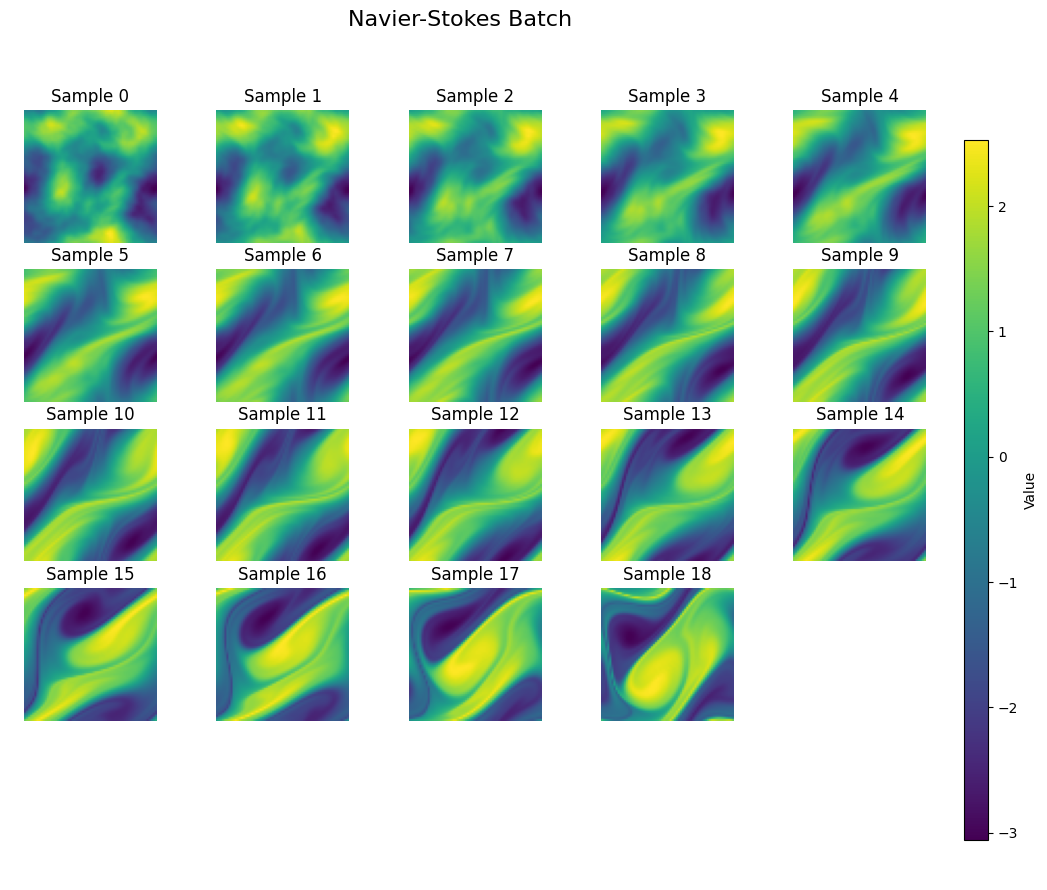

In [8]:
loader.visualize_batch('train', 'inputs', batch_size=19, start_idx=0, title="Navier-Stokes Batch")
# # show the entire 19-slice volumes for the first three cases
# loader.visualize_batch("train",
#                    batch_size=2,
#                    start_idx=0,
#                    full_volume=True,
#                    title="First case – full view")


In [9]:
# loader.visualize_batch('train', 'labels', batch_size=4, start_idx=0, title="Navier-Stokes Batch")

In [10]:
# import matplotlib.pyplot as plt
# import numpy as np # numpy is used in other cells, e.g. cell 11
# from ipywidgets import interact, IntSlider, fixed
# import ipywidgets as widgets

# # This cell creates an interactive plot with a slider to scroll through samples.
# # It assumes 'data' is defined in a previous cell (e.g., from cell 12: data = data['train']['inputs'][...,:1024])
# # and has a shape like (Height, Width, NumSamples).

# # Check if the 'data' variable exists and has the expected 3D shape
# if 'data' in globals() and isinstance(data, np.ndarray) and data.ndim == 3:
#     num_samples = data.shape[-1]

#     if num_samples == 0:
#         print("The 'data' array has no samples to display (last dimension is 0).")
#     else:
#         # Define the plotting function to be used with interact
#         def plot_sample(sample_idx, data_array):
#             fig, ax = plt.subplots(figsize=(8, 7)) # Adjusted figsize for better layout
            
#             current_sample_data = data_array[..., sample_idx]
#             img_display = ax.imshow(current_sample_data, cmap='viridis', aspect='auto')
#             ax.set_title(f"Sample {sample_idx + 1}/{num_samples}")
            
#             # Add a colorbar, using parameters similar to cell 11 for consistency
#             cbar = fig.colorbar(img_display, ax=ax, fraction=0.046, pad=0.04)
            
#             # Update color limits based on the new sample's data range
#             min_val, max_val = current_sample_data.min(), current_sample_data.max()
#             if min_val == max_val: # Avoid error if data is flat
#                 min_val -= 0.5
#                 max_val += 0.5
#             img_display.set_clim(vmin=min_val, vmax=max_val)
            
#             plt.show()

#         # Create the interactive slider
#         # The 'data' variable is passed as a fixed argument to avoid issues with large data in interact
#         interact(
#             plot_sample,
#             sample_idx=IntSlider(
#                 min=0, 
#                 max=num_samples - 1, 
#                 step=1, 
#                 value=0, 
#                 description='Sample Index:',
#                 continuous_update=False # Update plot only when slider is released
#             ),
#             data_array=fixed(data) 
#         )

# elif 'data' in globals():
#     print(f"The 'data' variable exists but is not a 3D numpy array as expected.")
#     if hasattr(data, 'shape'):
#         print(f"Current data shape: {data.shape}, Dtype: {type(data)}")
#     else:
#         print(f"Current data type: {type(data)}, does not have a shape attribute.")
# else:
#     print("The 'data' variable is not defined. Please ensure it is loaded and prepared in a previous cell.")
#     print("For example, cell 12 should define 'data = data['train']['inputs'][...,:1024]'.")


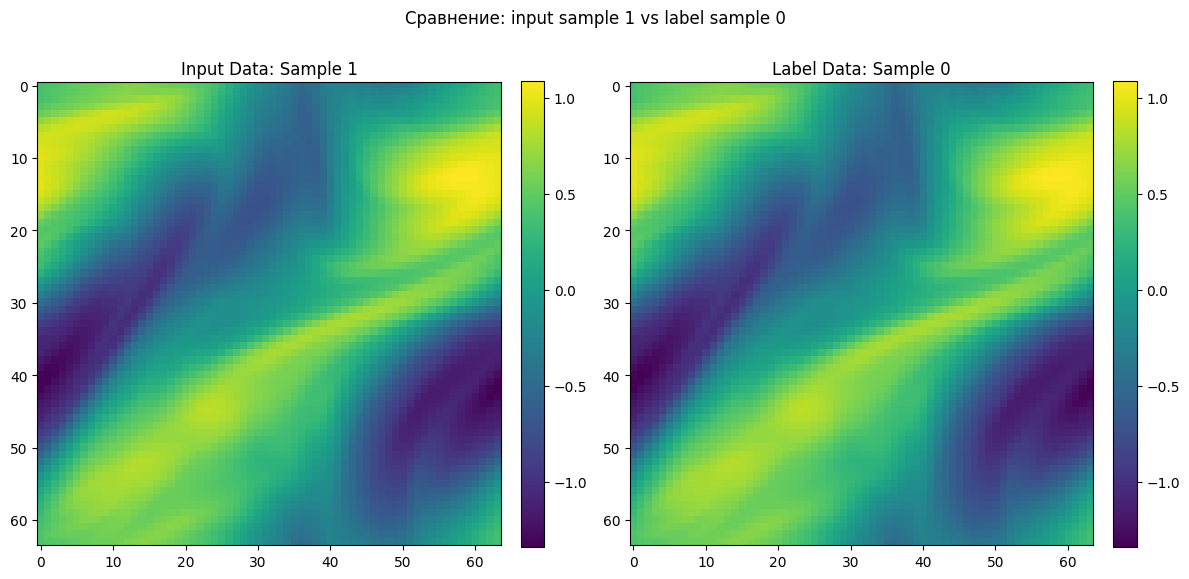

Среднее абсолютное отклонение: 0.000000
Максимальное отклонение: 0.000000
Совпадают ли значения массивов (np.array_equal): True
Совпадают ли значения с учетом погрешности (np.allclose): True


In [11]:
# Получаем sample1 из input_data и sample0 из label_data
sample1_input = data['train']['inputs'][...,5]
sample0_label = data['train']['labels'][...,4]

# Визуализируем оба среза рядом для сравнения
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
im0 = axes[0].imshow(sample1_input, cmap='viridis')
axes[0].set_title("Input Data: Sample 1")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(sample0_label, cmap='viridis')
axes[1].set_title("Label Data: Sample 0")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.suptitle("Сравнение: input sample 1 vs label sample 0")
plt.tight_layout()
plt.show()

# Можно также вывести числовую разницу
diff = sample1_input - sample0_label
print(f"Среднее абсолютное отклонение: {np.mean(np.abs(diff)):.6f}")
print(f"Максимальное отклонение: {np.max(np.abs(diff)):.6f}")

# Сравнение на равенство значений через numpy
are_equal = np.array_equal(sample1_input, sample0_label)
print(f"Совпадают ли значения массивов (np.array_equal): {are_equal}")

# Можно также проверить с учетом погрешности (например, для float)
are_close = np.allclose(sample1_input, sample0_label)
print(f"Совпадают ли значения с учетом погрешности (np.allclose): {are_close}")


In [12]:
# data= data['train']['inputs']["cases"]

In [13]:
data = data['train']['inputs'][...,:1024]

In [14]:
noisy_datasets = generate_noisy_datasets(
    data=data,
    noise_level=0.01,
    num_noisy_datasets=20,
    experiment_id="001"
)

train_data, test_data = split_data_in_memory_ordered(noisy_datasets, train_ratio=0.9)

subject_name = list(noisy_datasets.keys())[0]

print(list(noisy_datasets.keys()))
print(noisy_datasets[subject_name].shape)

Experiments processed: 100%|██████████| 20/20 [00:00<00:00, 11112.21it/s]

['noisy_dataset_1', 'noisy_dataset_2', 'noisy_dataset_3', 'noisy_dataset_4', 'noisy_dataset_5', 'noisy_dataset_6', 'noisy_dataset_7', 'noisy_dataset_8', 'noisy_dataset_9', 'noisy_dataset_10', 'noisy_dataset_11', 'noisy_dataset_12', 'noisy_dataset_13', 'noisy_dataset_14', 'noisy_dataset_15', 'noisy_dataset_16', 'noisy_dataset_17', 'noisy_dataset_18', 'noisy_dataset_19', 'noisy_dataset_20']
(64, 64, 1024)


In [15]:
# train_data, test_data = split_data_in_memory_ordered(data, train_ratio=0.9)

# subject_name = list(data.keys())[0]

# print(list(data.keys()))
# print(data[subject_name].shape)

### Load static csv data

In [16]:
# noisy_datasets = generate_noisy_datasets(
#     data=static_data,
#     noise_level=0.1,
#     num_noisy_datasets=5,
#     experiment_id="001"
# )

# train_data, test_data = split_data_in_memory_ordered(noisy_datasets, train_ratio=0.8)

# subject_name = list(noisy_datasets.keys())[0]

# print(list(noisy_datasets.keys()))
# print(noisy_datasets[subject_name].shape)

In [17]:
# # Load static tensor
# static_data = loader.load_data(Path("/Users/denissamatov/Heriot-Watt/tensor-based_modal_decomposition_method/data/HW static data"), "static", (286, 105, 100), tensor_type="pt")

# noisy_datasets = generate_noisy_datasets(
#     data=static_data,
#     noise_level=0.1,
#     num_noisy_datasets=5,
#     experiment_id="001"
# )

# train_data, test_data = split_data_in_memory_ordered(noisy_datasets, train_ratio=0.8)

# subject_name = list(noisy_datasets.keys())[0]

# print(list(noisy_datasets.keys()))
# print(noisy_datasets[subject_name].shape)

### Load dynamic csv data

In [18]:
# # Load dynamic tensor
# dynamic_data = loader.load_data(Path("/Users/denissamatov/Heriot-Watt/tensor-based_modal_decomposition_method/data/HW dynamic data"), "dynamic", (286, 105, 25, 253), tensor_type="pt")

# train_data, test_data = split_data_in_memory_ordered(dynamic_data, train_ratio=0.8)

# subject_name = list(dynamic_data.keys())[0]

# print(list(dynamic_data.keys()))
# print(dynamic_data[subject_name].shape)

### Load images


In [19]:
# # Load images tensor
# images_data, subject_list = loader.load_data(Path("/Users/denissamatov/Heriot-Watt/tensor-based_modal_decomposition_method/data/ExtendedYaleB/GroupedDataBySubject"), "images", tensor_type="pt")

# train_data, test_data = split_data_in_memory_ordered(images_data, train_ratio=0.8)

# subject_name = subject_list[0]

# print(subject_list)
# print(images_data[subject_name].shape)

In [20]:
# num_experiments = 2
# experiments_data = split_data_in_memory(images_data, num_experiments=num_experiments, train_ratio=0.8)

# if 1 not in experiments_data:
#     raise KeyError("Experiment ID 1 does not exist in 'experiments_data'.")

# train_data = experiments_data[1].get("train", {})
# test_data = experiments_data[1].get("test", {})

### Process data

In [21]:
# Decide what counts as background (CT example)
BG = None        # Hounsfield Units for air

# 1.  Build masks once if you have them, otherwise just pass background_value
train_global_min, train_global_max = calculate_global_minmax_params(train_data,
                                                                    background_value=BG)
train_global_mean, train_global_std = calculate_global_zscore_params(train_data,
                                                                     background_value=BG)

# 2.  Pack the globals
minmax_params = {'min': train_global_min, 'max': train_global_max}
zscore_params = {'mean': train_global_mean, 'std': train_global_std}

print(minmax_params)
print(zscore_params)

{'min': -3.244178295135498, 'max': 3.4058680534362793}
{'mean': 2.862924020519131e-06, 'std': 1.0884736776351929}


In [22]:
resize_shape = None
convert_to_grayscale = False
normalization_method = "minmax"  # "zscore" or "minmax"

print("Processing train data:")
train_tensors = process_data(
    train_data,
    resize_shape=resize_shape,
    convert_to_grayscale=convert_to_grayscale,
    normalization_method=normalization_method,
    global_params=minmax_params,
    background_value=BG
)

print("\nProcessing test data:")
test_tensors = process_data(
    test_data,
    resize_shape=resize_shape,
    convert_to_grayscale=convert_to_grayscale,
    normalization_method=normalization_method,
    global_params=minmax_params,
    background_value=BG
)

num_images_train = {subject: tensor.shape[-1] for subject, tensor in train_tensors.items()}
num_images_test  = {subject: tensor.shape[-1] for subject, tensor in test_tensors.items()}

if num_images_train:
    min_train_images = min(num_images_train.values())
    print(f"\nMinimum number of images in train: {min_train_images}")
else:
    print("\nNo data available for analysis in train.")

if num_images_test:
    min_test_images = min(num_images_test.values())
    print(f"Minimum number of images in test: {min_test_images}")
else:
    print("No data available for analysis in test.")

Processing train data:

DATA PROCESSING CONFIGURATION
▸ Resize shape:          No resizing
▸ Convert to grayscale:  False
▸ Normalization method:  minmax
  ↳ Global min/max:      -3.2442 / 3.4059
▸ Background value:      None



Processing subjects:  35%|███▌      | 7/20 [00:00<00:00, 65.48it/s]

noisy_dataset_1: (64, 64, 921)
noisy_dataset_2: (64, 64, 921)
noisy_dataset_3: (64, 64, 921)
noisy_dataset_4: (64, 64, 921)
noisy_dataset_5: (64, 64, 921)
noisy_dataset_6: (64, 64, 921)
noisy_dataset_7: (64, 64, 921)
noisy_dataset_8: (64, 64, 921)
noisy_dataset_9: (64, 64, 921)
noisy_dataset_10: (64, 64, 921)
noisy_dataset_11: (64, 64, 921)
noisy_dataset_12: (64, 64, 921)
noisy_dataset_13: (64, 64, 921)


Processing subjects: 100%|██████████| 20/20 [00:00<00:00, 63.13it/s]


noisy_dataset_14: (64, 64, 921)
noisy_dataset_15: (64, 64, 921)
noisy_dataset_16: (64, 64, 921)
noisy_dataset_17: (64, 64, 921)
noisy_dataset_18: (64, 64, 921)
noisy_dataset_19: (64, 64, 921)
noisy_dataset_20: (64, 64, 921)

Processing test data:

DATA PROCESSING CONFIGURATION
▸ Resize shape:          No resizing
▸ Convert to grayscale:  False
▸ Normalization method:  minmax
  ↳ Global min/max:      -3.2442 / 3.4059
▸ Background value:      None



Processing subjects: 100%|██████████| 20/20 [00:00<00:00, 584.58it/s]

noisy_dataset_1: (64, 64, 103)
noisy_dataset_2: (64, 64, 103)
noisy_dataset_3: (64, 64, 103)
noisy_dataset_4: (64, 64, 103)
noisy_dataset_5: (64, 64, 103)
noisy_dataset_6: (64, 64, 103)
noisy_dataset_7: (64, 64, 103)
noisy_dataset_8: (64, 64, 103)
noisy_dataset_9: (64, 64, 103)
noisy_dataset_10: (64, 64, 103)
noisy_dataset_11: (64, 64, 103)
noisy_dataset_12: (64, 64, 103)
noisy_dataset_13: (64, 64, 103)
noisy_dataset_14: (64, 64, 103)
noisy_dataset_15: (64, 64, 103)
noisy_dataset_16: (64, 64, 103)
noisy_dataset_17: (64, 64, 103)
noisy_dataset_18: (64, 64, 103)
noisy_dataset_19: (64, 64, 103)
noisy_dataset_20: (64, 64, 103)

Minimum number of images in train: 921
Minimum number of images in test: 103


# FTBMD algorithm

## Tensor HOSVD Algorithm

In [23]:
# Get list of all tensor keys
tensor_keys = list(train_tensors.keys())

# Initialize dictionaries to store cores and factors for each iteration
all_cores = {}
all_factors = {}

# Process tensors iteratively
for i in tqdm(range(2, len(tensor_keys)), desc="Processing tensors"):
    use_tensors = []
    
    # Create subset of tensors
    subset_tensors = {key: train_tensors[key] for key in tensor_keys[:i]}
    
    tbmd_decomposer = TuckerDecomposer(
        tensors=train_tensors,
        ranks=None,
        epsilon=1e-2,
        device='mps',   # 'cpu' or 'cuda' or 'mps'
        random_state=SEED   
    )


    # Perform decomposition
    tbmd_decomposer.decompose()

    all_cores[i] = tbmd_decomposer.cores
    all_factors[i] = tbmd_decomposer.factors
    
    # Print some info
    print(f"Iteration {i}: Processed {len(subset_tensors)} tensors")
    print(f"Number of cores: {len(all_cores[i])}")
use_tensors = set(use_tensors)

Processing tensors:   0%|          | 0/18 [00:00<?, ?it/s]INFO:TBMD.modules.TensorHOSVD:TensorProcessor initialized with device: mps, dtype: torch.float32
INFO:TBMD.modules.TensorHOSVD:TuckerDecomposerCore initialized with epsilon: 0.01
INFO:TBMD.modules.TensorHOSVD:TuckerDecomposerInterface initialized in collection mode
/Users/denissamatov/Heriot-Watt/tensor-based-modal-decomposition-method/venv/lib/python3.13/site-packages/tensorly/backend/__init__.py:202: UserWarning: The operator 'aten::linalg_svd' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:14.)
  return getattr(
INFO:TBMD.modules.TensorHOSVD:Decomposition completed successfully
Processing tensors:   6%|▌         | 1/18 [00:29<08:28, 29.89s/it]INFO:TBMD.modules.TensorHOSVD:TensorProcessor initialized with device: mps, dtype: torch.float32
INFO:TBMD.mod

Iteration 2: Processed 2 tensors
Number of cores: 20


INFO:TBMD.modules.TensorHOSVD:Decomposition completed successfully
Processing tensors:  11%|█         | 2/18 [00:57<07:34, 28.42s/it]INFO:TBMD.modules.TensorHOSVD:TensorProcessor initialized with device: mps, dtype: torch.float32
INFO:TBMD.modules.TensorHOSVD:TuckerDecomposerCore initialized with epsilon: 0.01
INFO:TBMD.modules.TensorHOSVD:TuckerDecomposerInterface initialized in collection mode


Iteration 3: Processed 3 tensors
Number of cores: 20


INFO:TBMD.modules.TensorHOSVD:Decomposition completed successfully
Processing tensors:  17%|█▋        | 3/18 [01:24<06:59, 27.94s/it]INFO:TBMD.modules.TensorHOSVD:TensorProcessor initialized with device: mps, dtype: torch.float32
INFO:TBMD.modules.TensorHOSVD:TuckerDecomposerCore initialized with epsilon: 0.01
INFO:TBMD.modules.TensorHOSVD:TuckerDecomposerInterface initialized in collection mode


...

Iteration 17: Processed 17 tensors
Number of cores: 20


INFO:TBMD.modules.TensorHOSVD:Decomposition completed successfully
Processing tensors:  94%|█████████▍| 17/18 [07:43<00:26, 26.85s/it]INFO:TBMD.modules.TensorHOSVD:TensorProcessor initialized with device: mps, dtype: torch.float32
INFO:TBMD.modules.TensorHOSVD:TuckerDecomposerCore initialized with epsilon: 0.01
INFO:TBMD.modules.TensorHOSVD:TuckerDecomposerInterface initialized in collection mode


Iteration 18: Processed 18 tensors
Number of cores: 20


INFO:TBMD.modules.TensorHOSVD:Decomposition completed successfully
Processing tensors: 100%|██████████| 18/18 [25:24<00:00, 84.69s/it] 

Iteration 19: Processed 19 tensors
Number of cores: 20


In [24]:
# # Save data with compression
# dump(all_cores, 'all_cores.joblib', compress=3)
# dump(all_factors, 'all_factors.joblib', compress=3)

In [25]:
# decomposer.reconstruct()
# error = decomposer.get_reconstruction_errors()
# error

## The joint modal tensor 𝐴

In [26]:
# # Later, load the data with:
# all_cores = load('all_cores.joblib')
# all_factors = load('all_factors.joblib')

In [27]:
# Create a list of paired cores and factors from the dictionaries
cores_list = []
factors_list = []
A_tensors = {}

# Extract all cores and factors with matching keys
common_keys = sorted(set(all_cores.keys()) & set(all_factors.keys()))
cores_list = [all_cores[key] for key in common_keys]
factors_list = [all_factors[key] for key in common_keys]

# Process each set of cores and factors to create A_tensors
for idx, (cores, factors) in enumerate(tqdm(zip(cores_list, factors_list), total=len(cores_list), desc="Creating joint modal tensors")):
    # Process all subjects to create modal tensors
    M_tensors = process_all_subjects(cores=cores, factors=factors, device='mps', return_numpy=False)
    
    # Stack all modes to create the joint modal tensor
    A_tensors[idx+1] = stack_all_modes(M_tensors, device='mps', return_numpy=False)

Creating joint modal tensors:   0%|          | 0/18 [00:00<?, ?it/s]/var/folders/3k/5p8p4n6n0ks6j1029qqcjckc0000gn/T/ipykernel_7319/2208489259.py:14: DeprecationWarning: process_all_subjects is deprecated. Use BatchModalProcessor.process_multiple_subjects() instead.
  M_tensors = process_all_subjects(cores=cores, factors=factors, device='mps', return_numpy=False)
INFO:TBMD.modules.TensorTimeInsensitiveModes:Initialized ModalTensorProcessor with device: mps
INFO:TBMD.modules.TensorTimeInsensitiveModes:Computed modal tensor with shape: torch.Size([64, 64, 64])
INFO:TBMD.modules.TensorTimeInsensitiveModes:Processed subject 'noisy_dataset_1' (1/20)
INFO:TBMD.modules.TensorTimeInsensitiveModes:Computed modal tensor with shape: torch.Size([64, 64, 64])
INFO:TBMD.modules.TensorTimeInsensitiveModes:Processed subject 'noisy_dataset_2' (2/20)
INFO:TBMD.modules.TensorTimeInsensitiveModes:Computed modal tensor with shape: torch.Size([64, 64, 64])
INFO:TBMD.modules.TensorTimeInsensitiveModes:Proces

## Tensor-based tube fiber-pivot QR Factorization

In [28]:
for key, tensor in A_tensors.items():
    print(f"Tensor A_tensors[{key}] shape: {tensor.shape}")

Tensor A_tensors[1] shape: torch.Size([64, 64, 1280])
Tensor A_tensors[2] shape: torch.Size([64, 64, 1280])
Tensor A_tensors[3] shape: torch.Size([64, 64, 1280])
Tensor A_tensors[4] shape: torch.Size([64, 64, 1280])
Tensor A_tensors[5] shape: torch.Size([64, 64, 1280])
Tensor A_tensors[6] shape: torch.Size([64, 64, 1280])
Tensor A_tensors[7] shape: torch.Size([64, 64, 1280])
Tensor A_tensors[8] shape: torch.Size([64, 64, 1280])
Tensor A_tensors[9] shape: torch.Size([64, 64, 1280])
Tensor A_tensors[10] shape: torch.Size([64, 64, 1280])
Tensor A_tensors[11] shape: torch.Size([64, 64, 1280])
Tensor A_tensors[12] shape: torch.Size([64, 64, 1280])
Tensor A_tensors[13] shape: torch.Size([64, 64, 1280])
Tensor A_tensors[14] shape: torch.Size([64, 64, 1280])
Tensor A_tensors[15] shape: torch.Size([64, 64, 1280])
Tensor A_tensors[16] shape: torch.Size([64, 64, 1280])
Tensor A_tensors[17] shape: torch.Size([64, 64, 1280])
Tensor A_tensors[18] shape: torch.Size([64, 64, 1280])


In [29]:
# Dictionary to store P matrices for each number of sensors
P_dict_all = {}  # {num_sensors: {subject_key: P, ...}, ...}
sensor_range = range(100, 201, 25)

for number_sensors in sensor_range:
    P_dict = {}
    print(f"\n=== Calculating for number_sensors = {number_sensors} ===")
    for idx, (subject_key, A_tensor) in tqdm(enumerate(A_tensors.items()), total=len(A_tensors), desc=f"QR decomposition (N={number_sensors})"):
        # Perform QR decomposition
        qr_decomposer = TensorTubeQRDecomposition(
            tensor=A_tensor,
            N=number_sensors,
            random_state=SEED,
            check_orthogonality=True,
            uniform_distribution=False
        )

        # Optionally, print progress
        if idx % 10 == 0:
            print(f"Performing QR factorization for subject {subject_key} ({idx+1}/{len(A_tensors)}) ...")
        P, Q, R = qr_decomposer.factorize()
        P_dict[subject_key] = P
    # Save for this number of sensors
    P_dict_all[number_sensors] = P_dict

# Optionally, save the results to disk (uncomment if needed)
# from joblib import dump
# dump(P_dict_all, "P_dict_all_sensors_10_200.joblib")


=== Calculating for number_sensors = 100 ===


QR decomposition (N=100):   0%|          | 0/18 [00:00<?, ?it/s]

Performing QR factorization for subject 1 (1/18) ...


QR decomposition (N=100):   6%|▌         | 1/18 [00:00<00:13,  1.27it/s]

QR Factorization completed:
  Requested sensors: 100
  Actual rank: 100
  Success rate: 100.0%
  Early stops: 0


...

QR Factorization completed:
  Requested sensors: 200
  Actual rank: 200
  Success rate: 100.0%
  Early stops: 0


QR decomposition (N=200):  94%|█████████▍| 17/18 [00:25<00:01,  1.55s/it]

QR Factorization completed:
  Requested sensors: 200
  Actual rank: 200
  Success rate: 100.0%
  Early stops: 0


QR decomposition (N=200): 100%|██████████| 18/18 [00:27<00:00,  1.52s/it]

QR Factorization completed:
  Requested sensors: 200
  Actual rank: 200
  Success rate: 100.0%
  Early stops: 0


In [30]:
# # Dictionary to store P matrices
# P_dict = {}
# number_sensors = 100

# for idx, (subject_key, A_tensor) in tqdm(enumerate(A_tensors.items()), desc="Performing QR decomposition"):
#     # Perform QR decomposition
#     qr_decomposer = TensorTubeQRDecomposition(
#         tensor=A_tensor,
#         N=number_sensors,
#         random_state=SEED,
#         check_orthogonality=True,
#         uniform_distribution=False
#     )

#     print("Performing QR factorization...")
#     P, Q, R = qr_decomposer.factorize()

#     if idx % 10 == 0:
#         print(f"Processed {idx+1}/{len(A_tensors)} subjects")
#     P_dict[subject_key] = P

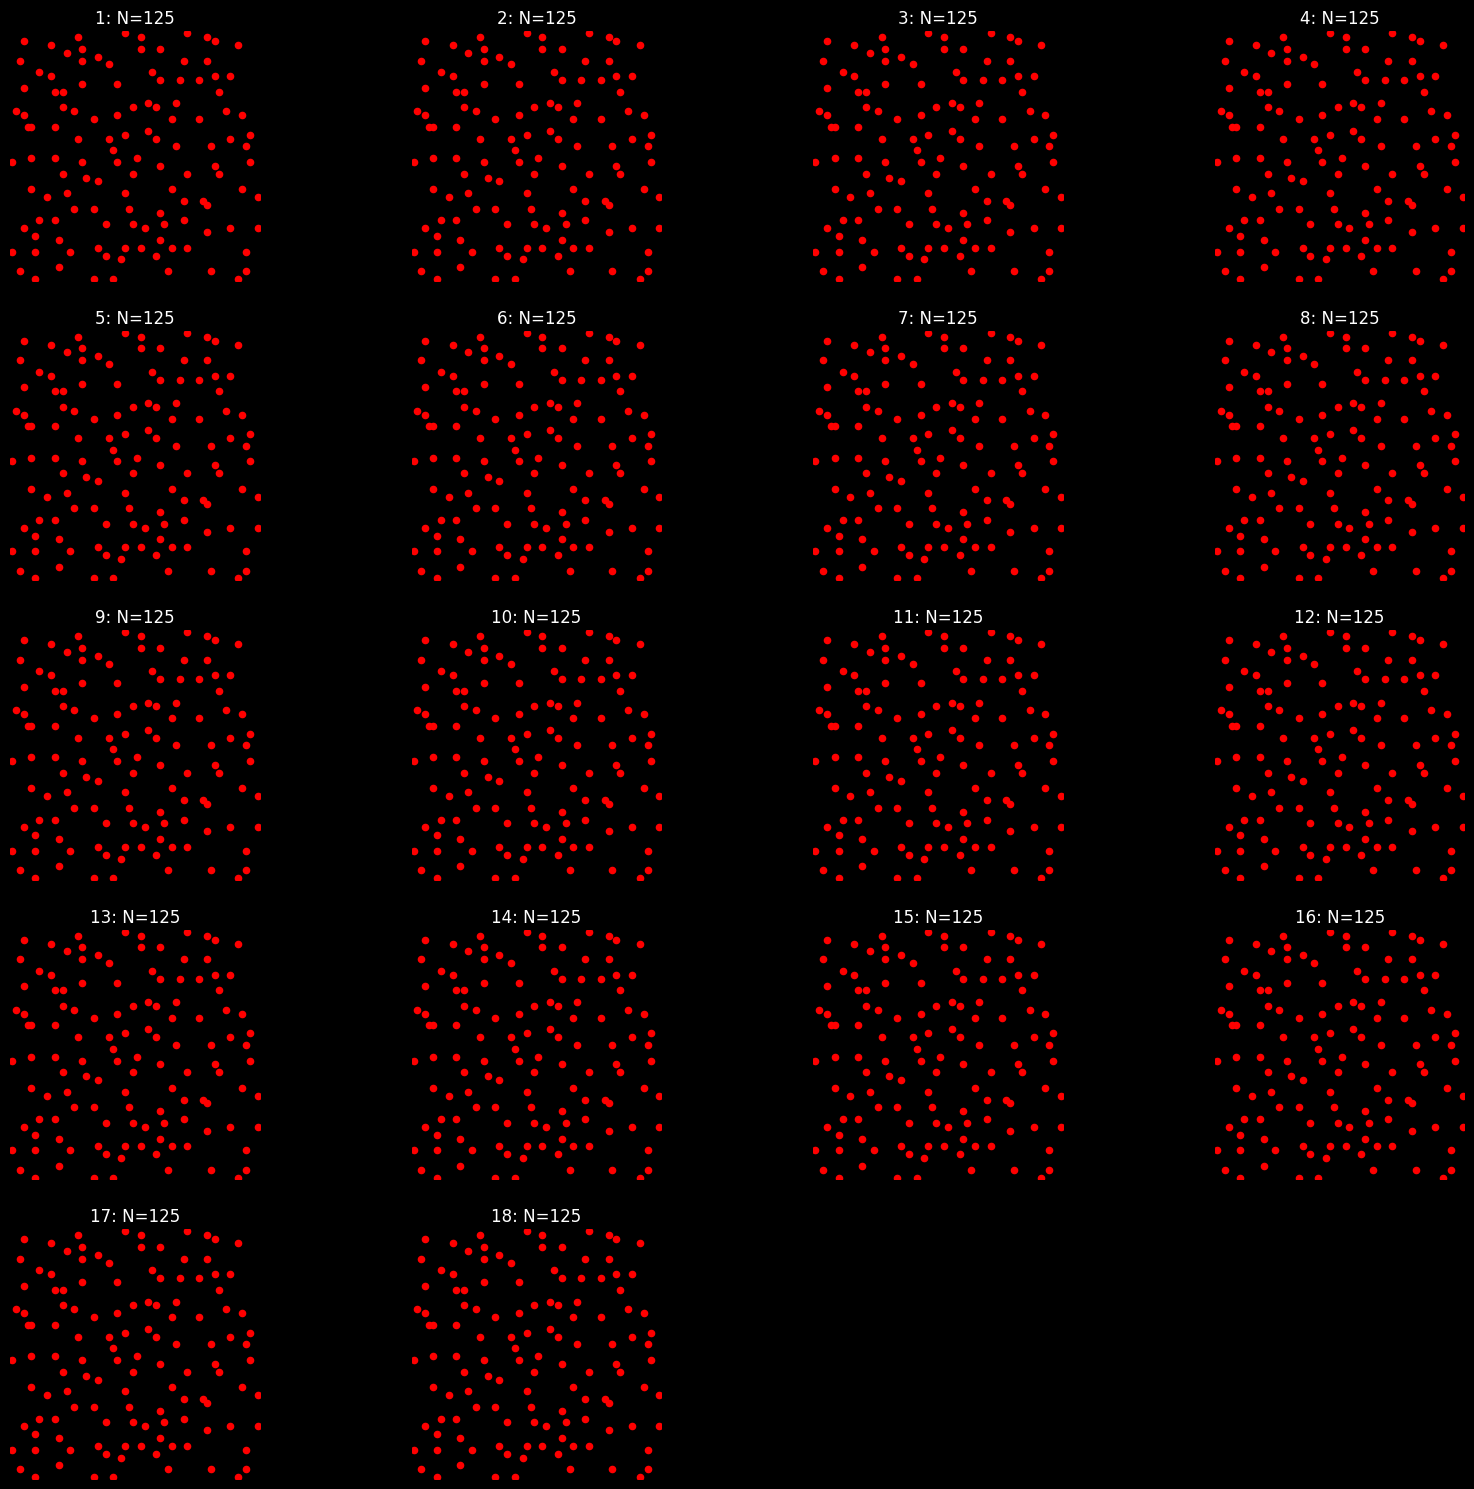

In [31]:
import math
import numpy as np
import matplotlib.pyplot as plt

def visualize_all_p_matrices(P_dict_all, num_sensors=None):
    """
    Visualize all P matrices for a given number of sensors from a nested dictionary
    {num_sensors: {subject_key: P, ...}, ...} in a grid layout.

    Parameters:
        P_dict_all (dict): Dictionary with num_sensors as keys and {subject_key: P, ...} as values
        num_sensors (int, optional): Which number of sensors to visualize. If None, uses the first key.
    """
    if num_sensors is None:
        # Use the first available number of sensors if not specified
        num_sensors = next(iter(P_dict_all.keys()))
    if num_sensors not in P_dict_all:
        raise ValueError(f"num_sensors={num_sensors} not found in P_dict_all keys: {list(P_dict_all.keys())}")

    P_dict = P_dict_all[num_sensors]
    num_subjects = len(P_dict)

    # Calculate grid dimensions (max 4 columns)
    ncols = min(4, num_subjects)
    nrows = math.ceil(num_subjects / ncols)

    # Create figure
    fig, axes = plt.subplots(nrows, ncols, 
                             figsize=(ncols * 4, nrows * 3),
                             facecolor='black')

    # Make axes iterable even if there's only one plot
    if num_subjects == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    # Process each P matrix
    for i, (subject_id, P) in enumerate(P_dict.items()):
        if i < len(axes):
            ax = axes[i]

            # Convert to numpy if it's a torch tensor
            if hasattr(P, 'detach') and hasattr(P, 'cpu'):
                p_cpu = P.detach().cpu().numpy()
            else:
                p_cpu = np.array(P)

            # Process dimensions like in original code
            if p_cpu.ndim == 2:
                sensor_map = p_cpu
            else:
                axes_to_proj = tuple(range(2, p_cpu.ndim))
                sensor_map = np.max(p_cpu, axis=axes_to_proj)

            # Set black background
            ax.set_facecolor("black")
            ax.imshow(np.zeros(sensor_map.shape), cmap="gray", origin="upper")

            # Plot sensor positions
            sensor_positions = np.argwhere(sensor_map == 1)
            if sensor_positions.size > 0:
                ax.scatter(sensor_positions[:, 1], sensor_positions[:, 0],
                          s=20, c="red", label="Sensors")

            # Set title and style
            ax.set_title(f"{subject_id}: N={len(sensor_positions)}", color="white")
            ax.axis("off")

    # Hide any unused subplots
    for j in range(num_subjects, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.1, hspace=0.2)
    plt.show()

# Example usage:
visualize_all_p_matrices(P_dict_all, num_sensors=125)

## Sparse measurements matrix Y

In [32]:
Y_matrices = {}

for item, (key, P) in enumerate(P_dict.items()):
    # Create a subset dictionary by taking the first item+1 items
    key, tensor = list(train_tensors.items())[item]
    print(key)
    subset_tensors = {key: tensor}

    Y_matrices[item+1] = build_Y_matrices(subset_tensors, P, device='mps')[key]


noisy_dataset_1
noisy_dataset_2
noisy_dataset_3
noisy_dataset_4
noisy_dataset_5
noisy_dataset_6
noisy_dataset_7
noisy_dataset_8
noisy_dataset_9
noisy_dataset_10
noisy_dataset_11
noisy_dataset_12
noisy_dataset_13
noisy_dataset_14
noisy_dataset_15
noisy_dataset_16
noisy_dataset_17
noisy_dataset_18


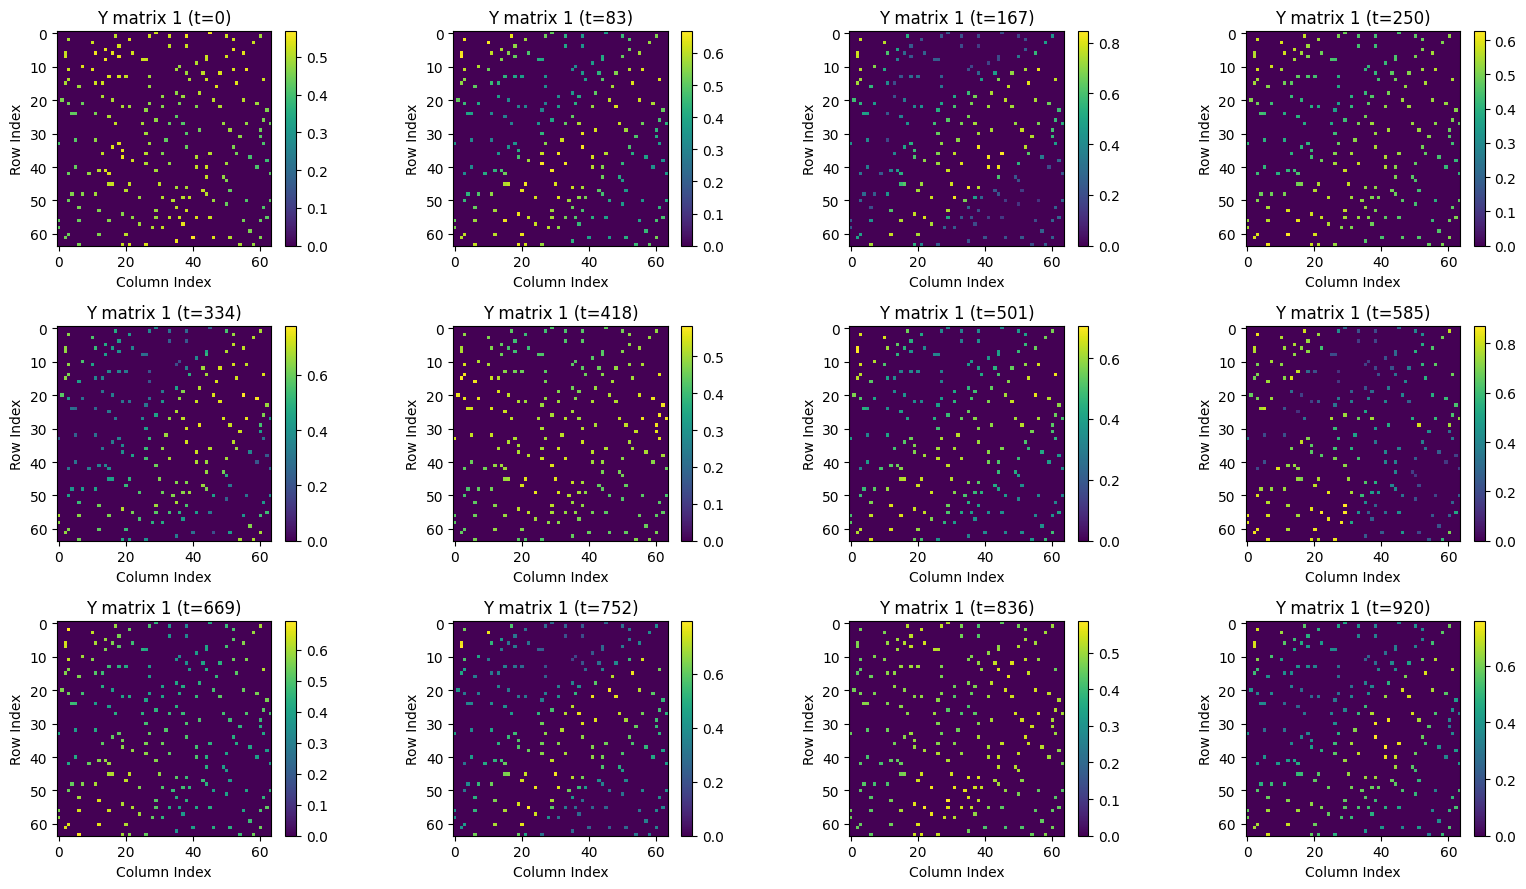

In [33]:
# Function to visualize a time sequence of Y matrices for a specific key
def visualize_y_matrix_sequence(Y_dict, key=1, time_indices=None, num_frames=4):
    """
    Visualize a sequence of time steps for a specific Y matrix.
    
    Parameters:
        Y_dict (dict): Dictionary with indices as keys and Y matrices as values
        key (int): Key of the Y matrix to visualize
        time_indices (list): List of time indices to visualize. If None, evenly spaced indices are used.
        num_frames (int): Number of frames to visualize if time_indices is None
    """
    if key not in Y_dict:
        print(f"Key {key} not found in Y_dict")
        return
    
    Y = Y_dict[key]
    
    # Convert to numpy if it's a torch tensor
    if hasattr(Y, 'detach') and hasattr(Y, 'cpu'):
        y_cpu = Y.detach().cpu().numpy()
    else:
        y_cpu = np.array(Y)
    
    # Handle dimension
    if y_cpu.ndim < 3:
        print("Y matrix doesn't have a time dimension")
        return
    
    # Get time dimension size
    time_dim = y_cpu.shape[2]
    
    # Select time indices to visualize
    if time_indices is None:
        time_indices = np.linspace(0, time_dim-1, num_frames, dtype=int)
    
    # Create subplot grid
    ncols = min(4, len(time_indices))
    nrows = math.ceil(len(time_indices) / ncols)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
    axes = np.array(axes).flatten()
    
    # Plot each time step
    for i, t_idx in enumerate(time_indices):
        if i < len(axes):
            ax = axes[i]
            
            # Get slice for this time step
            if t_idx < time_dim:
                data_slice = y_cpu[:, :, t_idx]
                
                # Plot
                im = ax.imshow(data_slice, cmap='viridis')
                plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
                
                ax.set_title(f"Y matrix {key} (t={t_idx})")
                ax.set_xlabel("Column Index")
                ax.set_ylabel("Row Index")
    
    # Hide any unused subplots
    for j in range(len(time_indices), len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Visualize a sequence of time steps for the first Y matrix
if Y_matrices:
    first_key = list(Y_matrices.keys())[0]
    visualize_y_matrix_sequence(Y_matrices, key=first_key, num_frames=12)

## Tensor-based Compressive Sensing Algorithm

In [34]:
max_iter = 1000
epsilon = 1e-2
lambd = 0.95
delta_0 = 0.1
delta_max = 1.0
solver_method = "triangular"    

test = 2
Y_matrix = Y_matrices[test]
A_tensor = A_tensors[test]
P = P_dict[test]
num_time_slices = Y_matrix.shape[2]

# Pre-allocate numpy array instead of appending to list
x_history_arr = np.zeros((num_time_slices, A_tensor.shape[2]))

# Use tqdm for progress tracking
for i in tqdm(range(num_time_slices), desc="Solving CS problems"):
    Y = Y_matrix[:, :, i].detach().cpu()

    cs_solver = TensorCompressiveSensing(
        A=A_tensor,
        P=P,
        Y=Y,
        max_iter=max_iter,
        epsilon=epsilon,
        lambd=lambd,
        delta_0=delta_0,
        delta_max=delta_max,
        solver_method=solver_method,
        device="cpu"
    )
    
    x_hat = cs_solver.solve()
    
    x_history_arr[i] = x_hat

Solving CS problems:   0%|          | 0/921 [00:00<?, ?it/s]


TypeError: TensorCompressiveSensing.__init__() got an unexpected keyword argument 'max_iter'

# Forecast next field matrix

### Linear model

In [ ]:
def run_linear_forecasting(x_history_arr):
    """
    Run linear forecasting on the given historical data.
    
    Args:
        x_history_arr: Historical data array of shape (T, W)
    """
    # Get dimensions
    T, W = x_history_arr.shape
    
    # Create forecaster
    forecaster = LinearForecaster(use_torch=False)
    
    # Train the model
    metrics = forecaster.train(x_history_arr, verbose=True)
    
    print("\nTraining Metrics:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.6f}")
    
    # Evaluate the model
    eval_metrics = forecaster.evaluate(x_history_arr)
    print("\nEvaluation Metrics:")
    for metric, value in eval_metrics.items():
        print(f"{metric}: {value:.6f}")
    
    # Predict next state
    x_curr = x_history_arr[-1]
    x_next = forecaster.predict_next(x_curr)
    print("\nPredicted next state:", x_next)
    
    # Predict future sequence
    future_seq = forecaster.predict_sequence(x_curr, n_steps=10)
    print("\nPredicted future sequence shape:", future_seq.shape)
    
    # Plot prediction comparison for selected features
    forecaster.plot_prediction_comparison(
        x_history_arr, 
        feature_indices=[0, 5, 10] if W > 10 else None,
        n_steps_ahead=10,
        figsize=(15, 8)
    )
    
    # Save the model (optional)
    # forecaster.save_model('models/linear_forecaster.npz')
    
    return forecaster, x_next, future_seq, metrics

: 

Training linear forecaster...
Training complete. RMSE: 0.03080, Rel. Frob. Err: 1.60339, R²: -1.87825

Training Metrics:
mse: 0.000948
rmse: 0.030798
rel_frob_err: 1.603392
r2: -1.878247

Evaluation Metrics:
mse: 0.000948
rmse: 0.030798
rel_frob_err: 1.603392
r2: -1.878247

Predicted next state: [ 4.22617946e-03 -1.09774201e-02  1.61275387e-03  8.06779504e-04
 -1.20821437e-02  1.57625701e-02 -1.01858476e-02  1.08738561e-02
 -2.26722468e-02  1.08352969e-03 -7.25261415e-03 -1.80450966e-02
  2.59989125e-02 -7.95828334e-03  4.20829176e-03 -1.86782453e-02
  2.75156513e-02 -2.87179673e-03  5.95309373e-03  5.43216783e-03
 -1.08191660e-02 -1.36134733e-02 -2.49047402e-03 -1.40115446e-03
 -4.19094381e-03  8.09174712e-03  9.73187367e-03  4.72266881e-03
 -5.99154912e-03 -1.36736761e-02  3.99663887e-03 -8.98800995e-03
 -2.52750574e-03  1.83684699e-02  1.13832605e-02 -8.85454466e-04
 -2.08487391e-03 -5.02582510e-04 -9.32506873e-03  7.25569989e-03
 -1.32983500e-02 -1.62100259e-02 -9.09404243e-03 -1.4

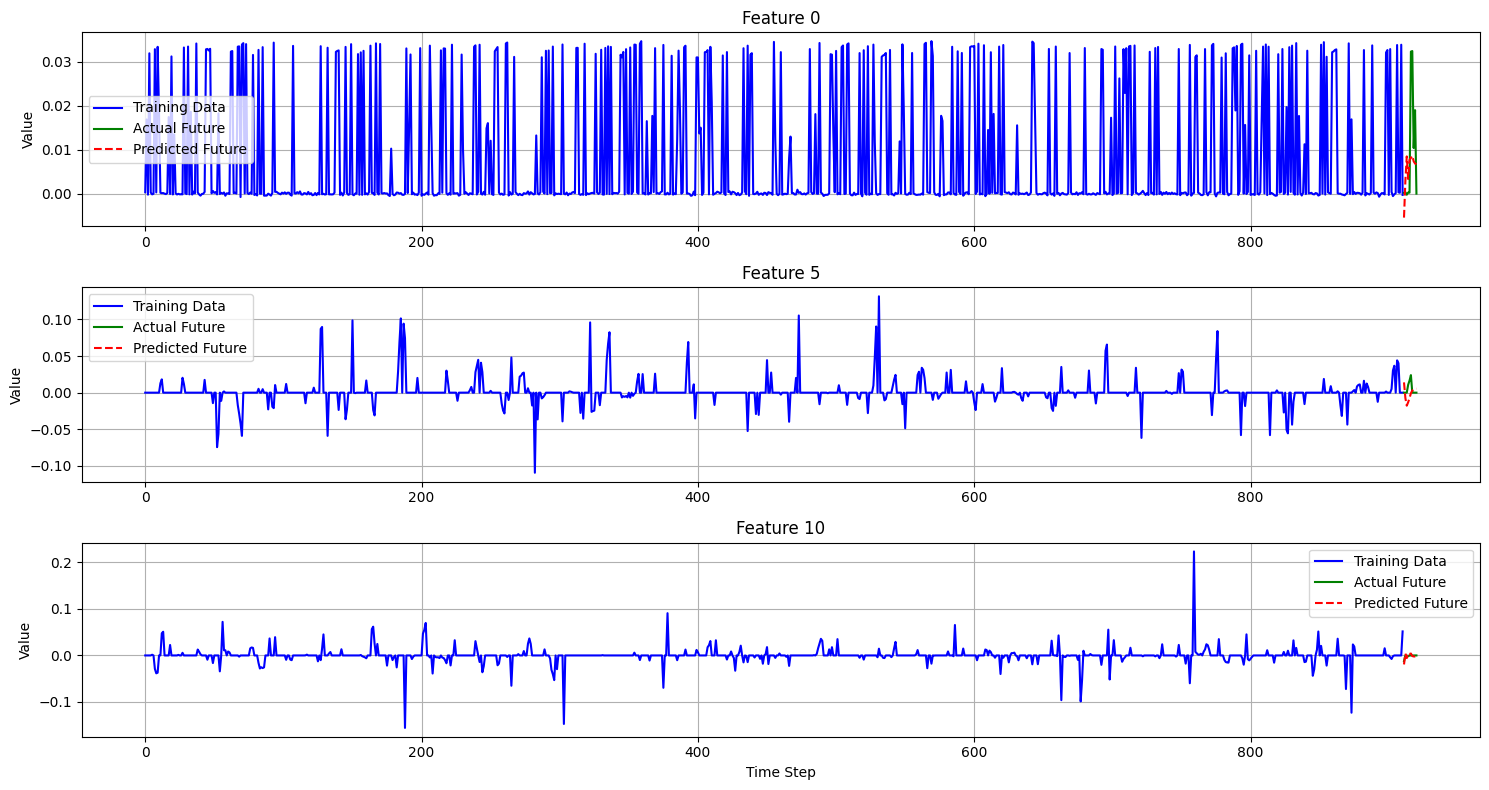

: 

In [ ]:
forecaster_linear, x_next_linear, future_seq_mlp, metrics_linear = run_linear_forecasting(x_history_arr)

### MLP

In [ ]:
def run_mlp_forecasting(x_history_arr):
    """
    Run MLP forecasting on the given historical data.
    
    Args:
        x_history_arr: Historical data array of shape (T, W)
    """
    # Get dimensions
    T, W = x_history_arr.shape
    
    # Create forecaster
    forecaster = MLPForecaster(
        in_dim=W,
        out_dim=W,
        hidden_dim=256,
        dropout_rate=0.3,
        num_layers=2,
        lr=1e-3,
        weight_decay=1e-5,
        device='cpu'  # or 'cuda', 'mps'
    )
    
    # Train the model
    history = forecaster.train(
        x_history_arr,
        num_epochs=500,
        batch_size=32,
        val_split=0.2,
        early_stopping_patience=20,
        verbose=True,
        save_best=True,
        model_path='models/mlp_forecaster.pth'
    )
    
    # Plot training history
    forecaster.plot_training_history()
    
    # Evaluate the model
    metrics = forecaster.evaluate(x_history_arr)
    print("\nEvaluation Metrics:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.6f}")
    
    # Predict next state
    x_curr = x_history_arr[-1]
    x_next = forecaster.predict_next(x_curr)
    print("\nPredicted next state:", x_next)
    
    # Predict future sequence
    future_seq = forecaster.predict_sequence(x_curr, n_steps=10)
    print("\nPredicted future sequence shape:", future_seq.shape)
    
    return forecaster, x_next, future_seq, metrics

: 

Using device: cpu
Epoch 50/500 - Train loss: 0.000364 - Val loss: 0.000382
Early stopping triggered after 83 epochs.
Training complete!


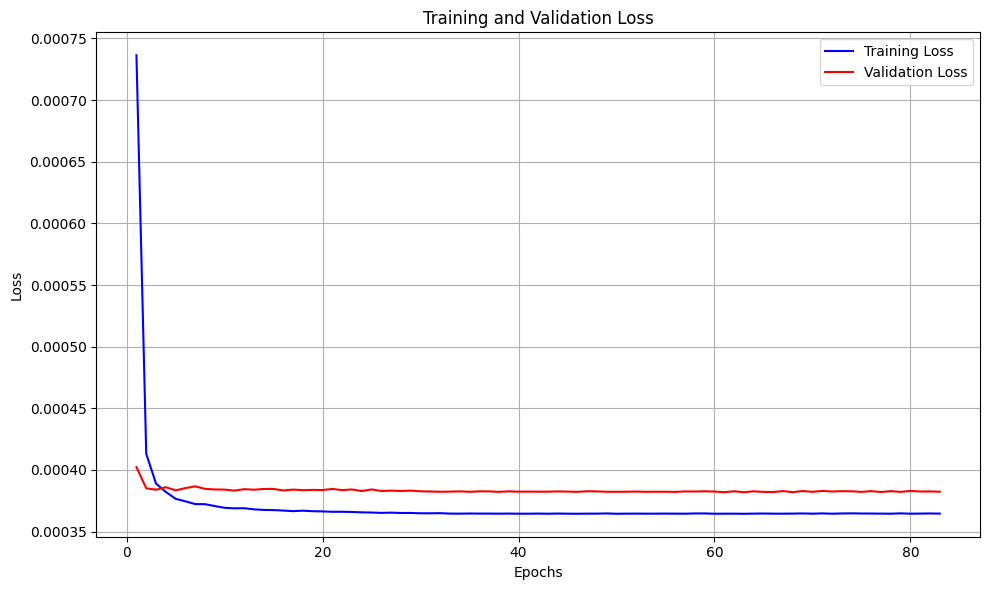


Evaluation Metrics:
mse: 0.000367
rmse: 0.019164
r2: 0.004441
rel_frob_err: 0.997700

Predicted next state: [ 7.2752098e-03  5.6610937e-04 -6.9275720e-04  7.7180663e-04
  1.8351401e-03  2.5894730e-03 -3.9115245e-04  6.1022828e-04
 -1.6264140e-03 -6.8863890e-05  4.1945994e-05 -8.3801802e-04
 -1.5076058e-03  1.3509655e-03  2.8344008e-05  6.1582011e-04
 -1.0619450e-03  1.7469141e-04 -1.0886471e-04 -8.1975252e-04
 -7.7437180e-05 -1.1530097e-03 -3.3137869e-05  5.3958141e-04
  6.7121844e-04  7.2129763e-04 -1.0790861e-03  1.1966969e-04
  8.2812866e-04  2.9806251e-04  9.1818621e-04  6.3414988e-04
  4.6258606e-04 -6.4437289e-04 -9.2437526e-04 -2.0511025e-05
 -1.9924909e-04  2.9044860e-04 -7.2080831e-05 -2.1649231e-04
 -2.0492061e-03  1.8885300e-03  8.2997396e-04  8.7186904e-04
  1.0601655e-03 -2.2692136e-03  7.7956247e-05  6.7230966e-04
  9.9692575e-04 -4.2652639e-04  3.3949522e-04  4.5690125e-05
 -1.6986289e-04  1.1032008e-03 -1.0626277e-04 -9.3355321e-04
 -1.0304765e-03 -1.6352767e-04 -3.132

: 

In [ ]:
forecaster_mlp, x_next_mlp, future_seq_mlp, metrics_mlp = run_mlp_forecasting(x_history_arr)

### LSTM

In [ ]:
def run_lstm_forecasting(x_history_arr, seq_length=5):
    """
    Run LSTM forecasting on the given historical data.
    
    Args:
        x_history_arr: Historical data array of shape (T, W)
        seq_length: Number of time steps to use for sequence input
    """
    # Get dimensions
    T, W = x_history_arr.shape
    
    # Create forecaster
    forecaster = LSTMForecaster(
        in_dim=W,
        out_dim=W,
        seq_length=seq_length,
        hidden_dim=64,
        num_layers=1,
        dropout_rate=0.0,
        lr=1e-3,
        weight_decay=1e-5,
        device='cpu'  # or 'cuda', 'mps'
    )
    
    # Train the model
    history = forecaster.train(
        x_history_arr,
        num_epochs=300,
        batch_size=32,
        val_split=0.2,
        early_stopping_patience=20,
        verbose=True,
        save_best=True,
        model_path='models/lstm_forecaster.pth'
    )
    
    # Plot training history
    forecaster.plot_training_history()
    
    # Evaluate the model
    metrics = forecaster.evaluate(x_history_arr)
    print("\nEvaluation Metrics:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.6f}")
    
    # Predict next state
    x_window = x_history_arr[-forecaster.seq_length:, :]
    x_next = forecaster.predict_next(x_window)
    print("\nPredicted next state:", x_next)
    
    # Predict future sequence
    future_seq = forecaster.predict_sequence(x_window, n_steps=10)
    print("\nPredicted future sequence shape:", future_seq.shape)
    
    return forecaster, x_next, future_seq, metrics

: 

Using device: cpu
Early stopping triggered after 27 epochs.
Training complete!


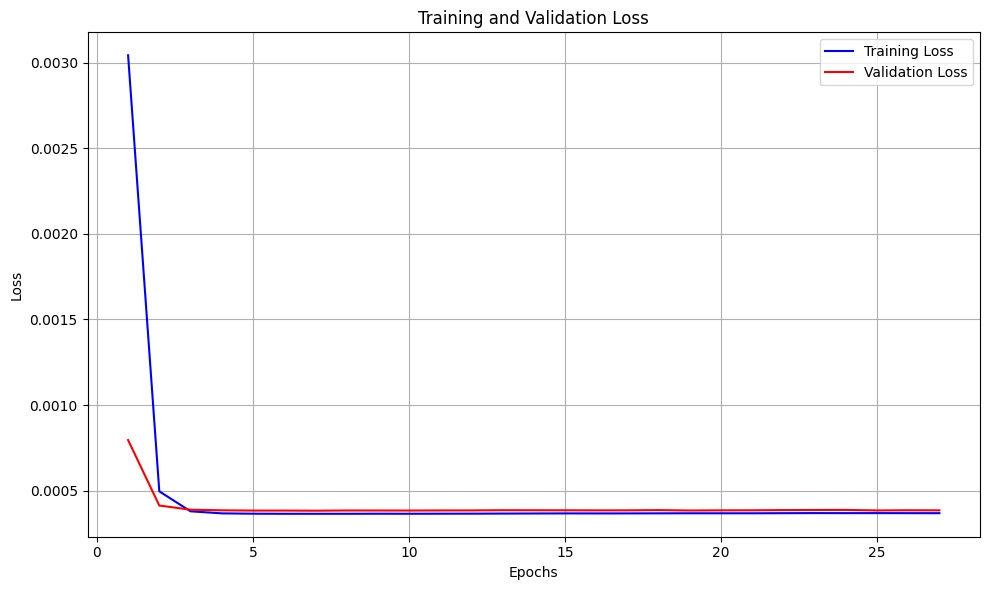


Evaluation Metrics:
mse: 0.000371
rmse: 0.019253
r2: -0.001693
rel_frob_err: 1.000786

Predicted next state: [ 8.19791202e-03  3.25858593e-03  1.38114067e-03 -9.29941423e-04
  1.66013092e-03  1.39139593e-06 -1.21577084e-03  7.74718821e-04
  1.01389177e-03  5.04668802e-04  3.23109329e-04 -2.44876370e-04
 -2.25733966e-03 -2.38254666e-04  2.44691968e-04  2.78684311e-03
 -1.05477870e-03  1.64445490e-03  2.16705352e-03 -3.27199511e-03
 -3.35001852e-03 -3.17625701e-04  9.14067030e-04  1.38212368e-03
  1.05300546e-03 -4.82201576e-05  1.52581185e-03  1.91652775e-03
  2.76330858e-04  3.55064683e-03  1.17784739e-03  1.69369578e-03
  2.68122181e-03  1.88068300e-03 -4.90549952e-04  8.62266868e-04
 -2.26418301e-03 -8.37534666e-04 -4.13795840e-03 -2.32196227e-03
 -1.53234205e-03  3.74235213e-04 -2.19404697e-04  5.47664240e-04
  1.48203969e-03 -3.22760455e-03 -3.67052853e-05 -1.08667091e-03
 -2.37023085e-03 -1.36912614e-03  2.94279400e-03  1.32068922e-03
 -1.07725803e-03 -1.31823542e-03 -2.14173645e

: 

In [ ]:
forecaster_lstm, x_next_lstm, future_seq_lstm, metrics_lstm = run_lstm_forecasting(x_history_arr, seq_length=5)

# Reconstruct the field matrix X

In [ ]:
import numpy as np
import torch
from skimage.metrics import structural_similarity
from typing import Union, Tuple, Optional




def calculate_error_and_ssim(
    A_re: Union[np.ndarray, torch.Tensor],
    A: Union[np.ndarray, torch.Tensor],
    background_value: float | None = None,
    mask: Optional[np.ndarray] = None,
) -> Tuple[float, float, float]:
    """
    Calculates reconstruction error, SSIM, and PSNR, optionally limited to the foreground.

    Parameters
    ----------
    A_re, A : np.ndarray | torch.Tensor
        Reconstructed and reference volumes. Must have the same dimensions.
    background_value : float, optional
        Scalar intensity value representing the background (e.g., -1000 for CT, 0 for MRI).
        Voxels equal to this value are excluded from both metrics when building the mask.
    mask : bool ndarray, optional
        Explicit foreground mask (True = foreground). Overrides `background_value`.

    Returns
    -------
    error : float
        Normalized Frobenius norm *only for foreground voxels*.
    ssim_value : float
        Structural Similarity Index, averaged across channels (if applicable).
        SSIM is calculated for the entire image/channel due to limitations in skimage.metrics.structural_similarity
        for directly applying an arbitrary mask to the SSIM computation process.
        Constants K1, K2 are chosen so that (K1*L)^2 and (K2*L)^2 correspond to C1=0.012 and C2=0.032 from the paper.
    psnr_value : float
        Peak Signal-to-Noise Ratio in decibels (dB), calculated only for foreground voxels.
    """
    # Convert torch.Tensor to numpy.ndarray
    if torch.is_tensor(A_re):
        A_re = A_re.detach().cpu().numpy()
    if torch.is_tensor(A):
        A = A.detach().cpu().numpy()

    A_re, A = np.asarray(A_re), np.asarray(A)

    # Check dimensions
    if A_re.shape != A.shape:
        raise ValueError("Dimensions of A_re and A must match.")

    # --- Building / validating mask ---
    if mask is None:
        if background_value is None:
            mask = np.ones_like(A, dtype=bool)   # The entire image is foreground
        else:
            mask = A != background_value
    else:
        mask = np.asarray(mask, dtype=bool)
        if mask.shape != A.shape:
            raise ValueError("Mask size must match input arrays.")

    if not mask.any():
        # If the mask is empty but we want to avoid an error, we could return (np.nan, np.nan)
        # or (np.inf, 0.0) depending on the desired behavior.
        # The paper doesn't specify this case. To match previous code, we'll raise an error.
        raise ValueError("Foreground mask is empty - nothing to compare.")

    # --- Frobenius error on the foreground (according to Equation 40 of the paper) ---
    # error_i = ||A_re_i - A_i||_F / ||A_i||_F
    # Applied to elements specified by the mask.
    
    # Numerator: norm of the difference on the mask
    diff_on_mask = A_re[mask] - A[mask]
    numerator_error_sq_sum = np.sum(np.square(diff_on_mask))

    # Denominator: norm of the original on the mask
    A_on_mask_sq_sum = np.sum(np.square(A[mask]))

    if A_on_mask_sq_sum == 0:
        # If the norm of the original on the mask is zero:
        # - If the reconstructed image on the mask is also zero (or identical), error is 0.
        # - Otherwise (original is 0, reconstructed is not 0), error tends to infinity.
        error = 0.0 if numerator_error_sq_sum == 0 else np.inf
    else:
        error = np.sqrt(numerator_error_sq_sum) / np.sqrt(A_on_mask_sq_sum)

    # --- SSIM ---
    # Constants C1 and C2 from the paper (p. 12)
    C1_paper = 0.01**2
    C2_paper = 0.03**2
    # C1_paper = 0.01
    # C2_paper = 0.03

    # data_range (L) is used to calculate K1, K2, so that (K_i * L)^2 = C_i_paper
    # In skimage.metrics.structural_similarity, C1=(K1*L)^2, C2=(K2*L)^2.
    # We calculate data_range across the entire reference image A.
    # If SSIM were strictly calculated on the mask, data_range could be A[mask].max() - A[mask].min().
    # However, since skimage.ssim doesn't directly accept a mask for the window process,
    # we use the global data_range.
    min_A, max_A = A.min(), A.max()
    data_range = max_A - min_A

    # Handle the case when data_range is very small (practically 0)
    if data_range < 1e-6: # Threshold to prevent floating point issues
        # If there are no variations in the reference image:
        # SSIM = 1.0 if images are identical, otherwise can be considered 0.0 (or another value).
        # np.allclose is used to compare floating point arrays.
        if np.allclose(A_re, A):
            ssim_value = 1.0
        else:
            # If images are not identical, but data_range=0, SSIM is not very meaningful.
            # skimage.ssim might return NaN or another value. It's safer to set 0.0.
            ssim_value = 0.0
    else:
        # Calculate K1 and K2 for skimage.ssim to match C1_paper and C2_paper
        K1 = np.sqrt(C1_paper) / data_range
        K2 = np.sqrt(C2_paper) / data_range
        
        # Make sure K1 and K2 are not too large if data_range is very small but not zero.
        # This can happen if C1_paper, C2_paper are not intended for such scaling.
        # However, we follow the formula.

        # Define win_size. Must be odd and <= min(image dimensions).
        # skimage uses 7 by default. If the image size is smaller, it adapts.
        # Explicitly set to None so skimage uses its default logic (7 or less).
        win_size = None # Allows skimage to choose an appropriate win_size (usually 7 or less)

        if A.ndim == 2:
            # IMPORTANT: skimage.metrics.structural_similarity does NOT accept a 'mask' argument.
            # The comment in the original code "skimage >= 0.19 supports a 'mask' keyword" for ssim is incorrect.
            # Therefore, SSIM is calculated for the entire image (or channel).
            ssim_value = structural_similarity(
                A, A_re, # Order: Reference, Reconstructed
                win_size=win_size,
                data_range=data_range,
                K1=K1,
                K2=K2,
                channel_axis=None, # For 2D image, explicitly indicate no channel axis
                gaussian_weights=True # Standard behavior
            )
        elif A.ndim >= 3: # Assume the last axis is channels
            ssim_values_per_channel = []
            for c in range(A.shape[-1]):
                # Define win_size for each 2D slice of the channel
                current_win_size = None # skimage will determine for the slice A[...,c]
                if A.shape[0] < 7 or A.shape[1] < 7 : # If slice dimensions are less than 7
                     current_win_size = min(A.shape[0], A.shape[1])
                     if current_win_size % 2 == 0: # win_size must be odd
                         current_win_size = max(1, current_win_size -1)


                channel_ssim = structural_similarity(
                    A[..., c], A_re[..., c], # Order: Reference, Reconstructed
                    win_size=current_win_size,
                    data_range=data_range, # data_range is usually global for all channels
                    K1=K1,
                    K2=K2,
                    channel_axis=None, # Process each channel as a 2D image
                    gaussian_weights=True
                )
                ssim_values_per_channel.append(channel_ssim)
            ssim_value = np.mean(ssim_values_per_channel)
        else: # Unexpected number of dimensions
            raise ValueError(f"Unsupported number of dimensions for SSIM: {A.ndim}")

    # Handle NaN in ssim_value, which could occur (although previous logic tries to prevent this)
    if np.isnan(ssim_value):
        # This can happen if, for example, K1/K2 became NaN due to data_range=0,
        # but this case should already be handled.
        # If still NaN, can set to 0 as a safe value.
        ssim_value = 0.0

    # --- PSNR calculation (Peak Signal-to-Noise Ratio) ---
    # PSNR = 20 * log10(MAX_I / sqrt(MSE))
    # where MAX_I is the maximum possible pixel value and MSE is Mean Squared Error
    # We calculate PSNR only for foreground voxels (using the mask)
    
    # Calculate MSE on the masked region
    mse_on_mask = np.mean(np.square(diff_on_mask))
    
    if mse_on_mask == 0:
        # Perfect reconstruction - PSNR is infinite
        psnr_value = np.inf
    else:
        # Maximum possible pixel value is determined from the data range of the reference image
        # We use the global data_range calculated earlier for consistency with SSIM
        max_pixel_value = data_range
        
        # Handle edge case where data_range is very small
        if max_pixel_value < 1e-6:
            # If there's no variation in the reference image, PSNR is not meaningful
            # Set to a high value if images are identical, 0 otherwise
            if np.allclose(A_re[mask], A[mask]):
                psnr_value = np.inf
            else:
                psnr_value = 0.0
        else:
            # Standard PSNR calculation
            psnr_value = 20 * np.log10(max_pixel_value / np.sqrt(mse_on_mask))

    # Handle potential NaN or infinite values
    if np.isnan(psnr_value):
        psnr_value = 0.0
    elif np.isinf(psnr_value) and mse_on_mask > 0:
        # If PSNR is infinite but MSE > 0, something went wrong
        psnr_value = 0.0

    return float(error), float(ssim_value), float(psnr_value)


: 

In [ ]:
key = list(test_tensors.keys())[test]

X = test_tensors[key][...,0]

: 

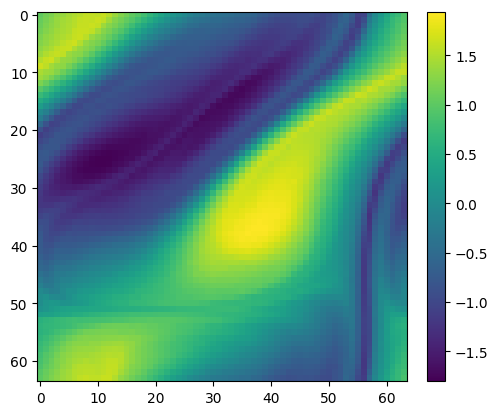

: 

In [ ]:
fig, ax = plt.subplots()
im = ax.imshow(original_X)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

In [ ]:
# Convert NumPy arrays to PyTorch tensors
x_next_linear_tensor = torch.from_numpy(x_next_linear).to(A_tensors[test].dtype)
x_next_mlp_tensor = torch.from_numpy(x_next_mlp).to(A_tensors[test].dtype)
x_next_lstm_tensor = torch.from_numpy(x_next_lstm).to(A_tensors[test].dtype)

# Use the tensors for reconstruction
X_reconstructed_linear = reconstruct_tensor(A_tensor=A_tensors[test], x_hat=x_next_linear_tensor)
X_reconstructed_mlp = reconstruct_tensor(A_tensor=A_tensors[test], x_hat=x_next_mlp_tensor)
X_reconstructed_lstm = reconstruct_tensor(A_tensor=A_tensors[test], x_hat=x_next_lstm_tensor)

Reconstructed tensor shape: torch.Size([64, 64]), mode used: 2
Reconstructed tensor shape: torch.Size([64, 64]), mode used: 2
Reconstructed tensor shape: torch.Size([64, 64]), mode used: 2


: 

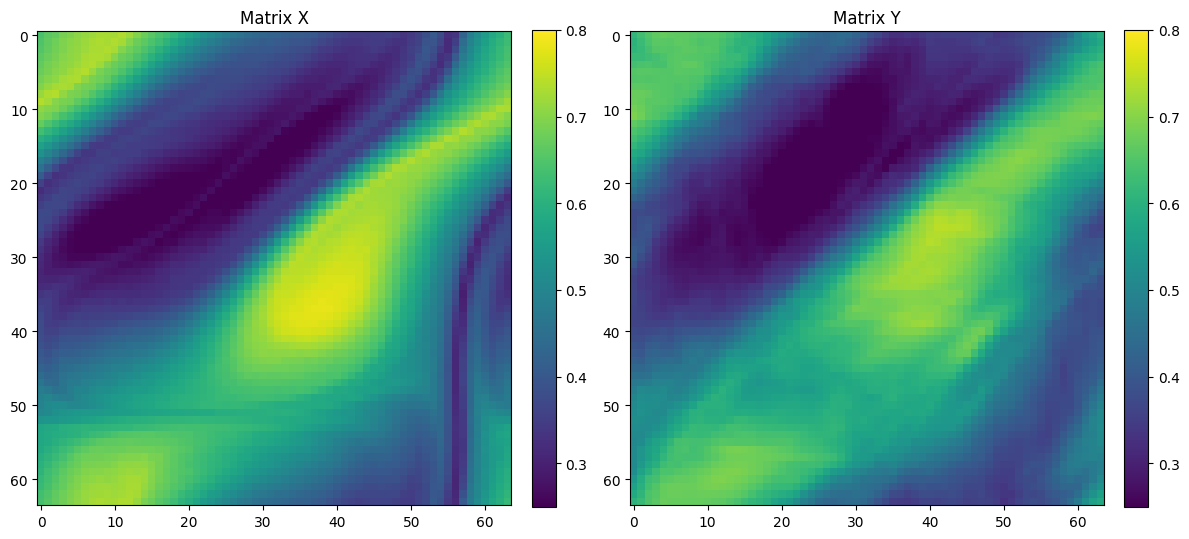

: 

In [ ]:
plot_two_matrices(X, X_reconstructed_linear, zmin=0.25, zmax=0.8)

In [ ]:
error, ssim_value, psnr_value = calculate_error_and_ssim(X, X_reconstructed_linear)

print(f"Reconstruction Error (error): {error:.5f}")
print(f"Structural Similarity Index (SSIM): {ssim_value:.5f}")
print(f"Peak Signal-to-Noise Ratio (PSNR): {psnr_value:.5f}")

Reconstruction Error (error): 0.08477
Structural Similarity Index (SSIM): 0.81579
Peak Signal-to-Noise Ratio (PSNR): 22.26406


: 

In [ ]:
original_X = inverse_normalization(X, normalization_method=normalization_method, global_params=minmax_params)
original_X_reconstructed = inverse_normalization(X_reconstructed_linear, normalization_method=normalization_method, global_params=minmax_params)

: 

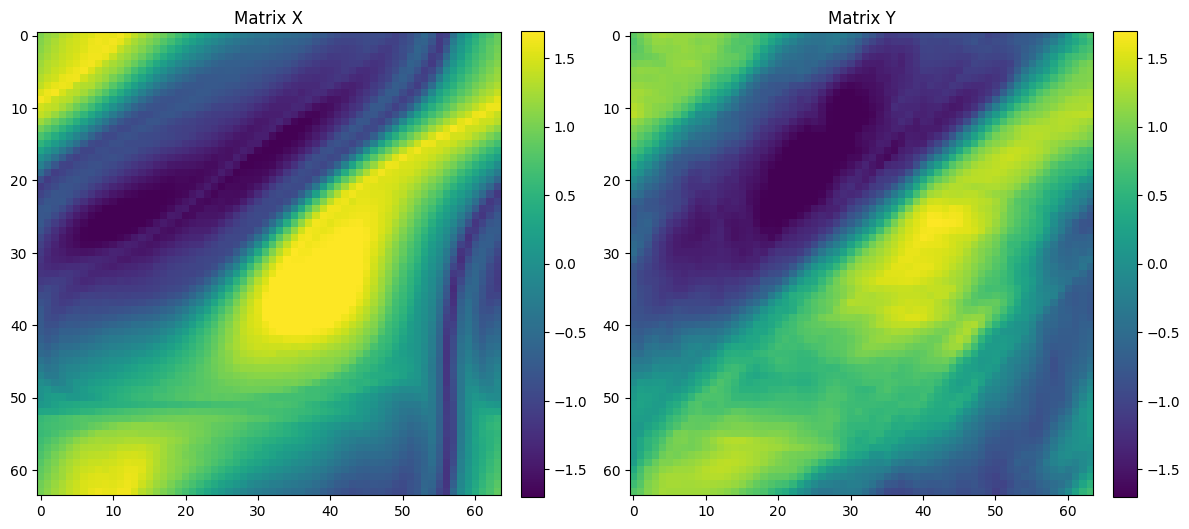

: 

In [ ]:
plot_two_matrices(original_X, original_X_reconstructed, zmin=-1.7, zmax=1.7)

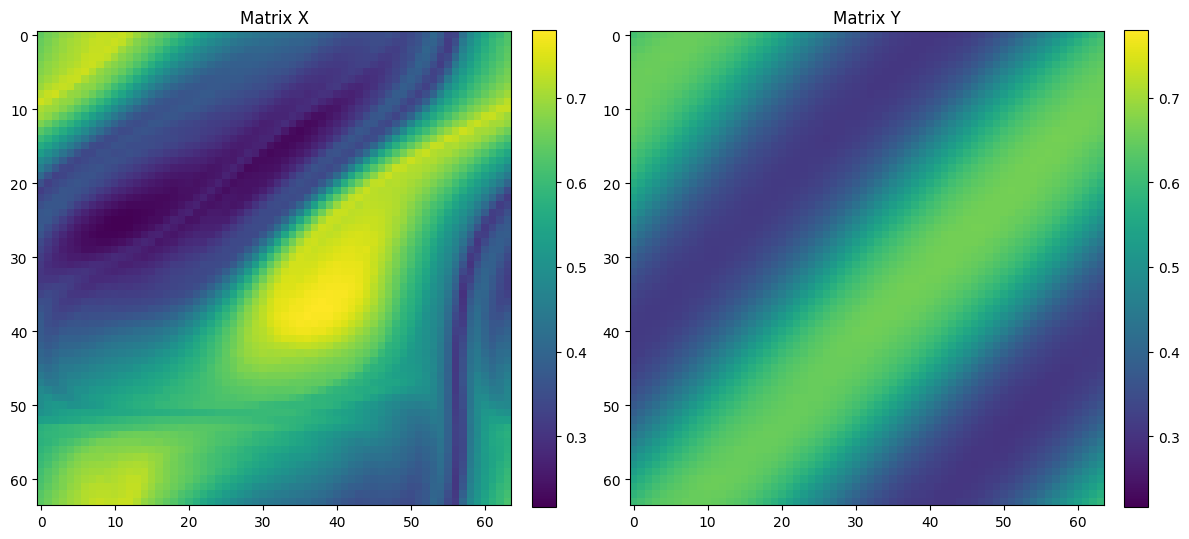

: 

In [ ]:
plot_two_matrices(X, X_reconstructed_mlp)

In [ ]:
error, ssim_value, psnr_value = calculate_error_and_ssim(X, X_reconstructed_mlp)

print(f"Reconstruction Error (error): {error:.5f}")
print(f"Structural Similarity Index (SSIM): {ssim_value:.5f}")
print(f"Peak Signal-to-Noise Ratio (PSNR): {psnr_value:.5f}")

Reconstruction Error (error): 0.16887
Structural Similarity Index (SSIM): 0.76391
Peak Signal-to-Noise Ratio (PSNR): 12.59815


: 

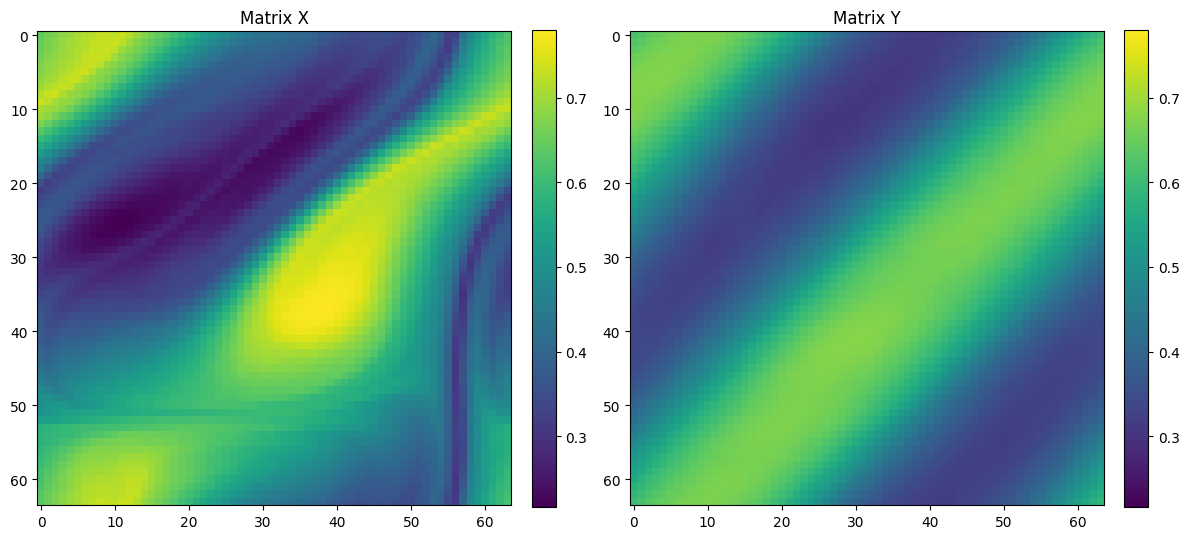

: 

In [ ]:
plot_two_matrices(X, X_reconstructed_lstm)

In [ ]:
error, ssim_value, psnr_value = calculate_error_and_ssim(X, X_reconstructed_lstm)

print(f"Reconstruction Error (error): {error:.5f}")
print(f"Structural Similarity Index (SSIM): {ssim_value:.5f}")
print(f"Peak Signal-to-Noise Ratio (PSNR): {psnr_value:.5f}")

Reconstruction Error (error): 0.15824
Structural Similarity Index (SSIM): 0.76708
Peak Signal-to-Noise Ratio (PSNR): 13.28640


: 

In [ ]:
# origial_X = inverse_normalization(X, normalization_method=normalization_method, global_params=global_params)
# origial_X_reconstructed = inverse_normalization(X_reconstructed, normalization_method=normalization_method, global_params=global_params)

: 

In [ ]:
# fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# axes[0].imshow(origial_X, cmap='gray')
# axes[0].set_title('Matrix X')
# axes[0].set_xlabel('Column Index')
# axes[0].set_ylabel('Row Index')

# axes[1].imshow(origial_X_reconstructed, cmap='gray')
# axes[1].set_title('Reconstructed Matrix X')
# axes[1].set_xlabel('Column Index')
# axes[1].set_ylabel('Row Index')

# plt.tight_layout()
# plt.show()

: 

: 